# Análisis Exploratorio de Datos Abiertos Nuevo León

Este notebook documenta las características principales encontradas al analizar los metadatos extraídos de cada una de las bases de datos que se encuentran en el portal de datos en formato abierto del Gobierno del Estado de Nuevo León.

Se trabaja con dos archivos, obtenidos mediante *webscraping* del catálogo (con una semana de diferencia entre ambos, por lo que algunas bases de datos pueden no coincidir entre uno y otro):
- **`catalogo_datos.csv`**: metadatos de cada base de datos publicada (organización, fechas, licencia, etiquetas, etc.).
- **`tabla_variables.csv`**: diccionario de variables de cada base de datos (nombre, tipo, descripción y % de valores faltantes).

El objetivo es identificar la calidad y completitud de los metadatos, detectar errores o inconsistencias de la plataforma, y sentar las bases para futuros proyectos con estos datos.

In [1]:
import pandas as pd

Se importa un archivo CSV con los metadatos de cada una de las bases de datos disponibles en la página:

In [2]:
df = pd.read_csv('catalogo_datos.csv', encoding='latin1')
display(df.head())

,Nombre de la base de datos,Diccionario (Si/No),Fuente,Autor,Mantenedor,Ultima actualizacion,Fecha de creacion,Periodo de actualizacion,Proxima actualizacion,Etiquetas,Organizacion de origen,Grupos,Formatos,Licencia,Descripcion de la base de datos,_id_ckan,_metadata_modified_raw
0,Matricula Universidad Politécnica de Apodaca,Si,NaN,Universidad Politécnica de Apodaca,Karen Migdalia Juárez Soto,2026-08-26,2026-06-15,Cuatrimestral,Agosto 2026,NaN,Universidad Politécnica de Apodaca,Educación,CSV,Open Data Commons Attribution License,Concentrado del Alumnado de la Universidad Pol...,dadfe381-e28a-4c48-a382-e02fdb163452,2026-08-26T17:17:42.176192
1,Atenciones Ciudadanas,Si,NaN,Instituto Registral y Catastral del estado de ...,José Eligio Castro Colunga,2026-08-26,2026-07-28,mensual,junio 2026,atencion ciudadana,Instituto Registral y Catastral del Estado de ...,Atención Ciudadana; Transparencia y Combate a ...,CSV,Open Data Commons Attribution License,Frecuencia de atenciones a usuarios brindadas ...,3e66faca-5615-482a-a890-fb4c94011fef,2026-08-26T16:31:01.014505
2,Conciliaciones Laborales,Si,NaN,Jefatura de Informática,Alejandra Arellano,2026-08-24,2026-02-23,Mensual,AGOSTO 2026,conciliacion,Centro de Conciliación Laboral,Administración y Finanzas,CSV,Open Data Commons Attribution License,Conjunto de datos que contiene información sob...,6120e6bb-dd0c-40fd-8e3f-aaf134f4ea85,2026-08-24T19:42:08.235165
3,Contrataciones Abiertas de la Dirección Genera...,No,NaN,Dirección General de Adquisiciones y Servicios,Alejandra Mariana Torres y Adolfo Alanis Vázquez,2026-08-24,2024-11-11,Semanal,22 de Septiembre,Administración; Compras; EDCA; contrataciones ...,Secretaría de Administración,Administración y Finanzas,"JSON, URL",Creative Commons Attribution,JSON con la información de la Dirección Genera...,3d21eab2-f620-4d18-8055-78e13836cc6a,2026-08-24T15:16:11.542448
4,PIB Agroindustrial por Entidad Federativa 2022...,Si,https://www.inegi.org.mx/app/tabulados/pxwebcl...,Unidad de Enlace de Proyectos e Información Se...,Jair Zamuel García Ortiz,2026-08-17,2026-02-20,Anual,Enero 2027,Agroindustria; PIB,Secretaría de Desarrollo Regional y Agropecuario,Agroalimentario,CSV,Open Data Commons Attribution License,Conjunto de datos que muestra el PIB Agroindus...,ddbaf423-b6fe-4fe5-bc92-1004be4f8168,2026-08-17T23:29:53.680322


Características del DataFrame:

In [3]:
df.shape

(125, 17)

In [4]:
df.columns

Index(['Nombre de la base de datos', 'Diccionario (Si/No)', 'Fuente', 'Autor',
       'Mantenedor', 'Ultima actualizacion', 'Fecha de creacion',
       'Periodo de actualizacion', 'Proxima actualizacion', 'Etiquetas',
       'Organizacion de origen', 'Grupos', 'Formatos', 'Licencia',
       'Descripcion de la base de datos', '_id_ckan',
       '_metadata_modified_raw'],
      dtype='str')

In [5]:
df.dtypes

Nombre de la base de datos         str
Diccionario (Si/No)                str
Fuente                             str
Autor                              str
Mantenedor                         str
Ultima actualizacion               str
Fecha de creacion                  str
Periodo de actualizacion           str
Proxima actualizacion              str
Etiquetas                          str
Organizacion de origen             str
Grupos                             str
Formatos                           str
Licencia                           str
Descripcion de la base de datos    str
_id_ckan                           str
_metadata_modified_raw             str
dtype: object

### Tipos de Datos del DataFrame `df`

La siguiente tabla muestra los tipos de datos con los que `pandas` cargó cada columna del DataFrame `df`:

*   **`object` / `str`:** todas las columnas se cargan como texto, incluyendo `'Ultima actualizacion'` y `'Fecha de creacion'`, que en el CSV original son fechas escritas como texto (por ejemplo `'2026-08-26'`).
*   Más adelante, cuando se necesiten como fechas para graficar o calcular vigencias, estas dos columnas se convierten puntualmente con `pd.to_datetime(...)` en las celdas correspondientes — no se hace de una vez aquí para evitar sobrescribir el DataFrame antes de mostrar su forma "cruda" tal como llega del CSV.
*   **Periodo de Actualización:** la columna `'Periodo de actualizacion'` mezcla mayúsculas/minúsculas y contiene al menos un valor claramente mal capturado (una fecha, `'mayo 2026'`, en vez de una periodicidad). Más adelante se estandariza y se documenta este error como un hallazgo de calidad de la plataforma.

Tener claro qué columnas son texto y cuáles requieren conversión evita errores de tipo en los análisis siguientes.

### ¿Cuántas bases de datos hay?

In [6]:
num_databases = len(df)
print(f"Hay {num_databases} bases de datos en total.")

Hay 125 bases de datos en total.


### Gráfica de fechas de creación

Para poder graficar por fecha, aquí es donde `'Fecha de creacion'` se convierte por primera vez a un tipo de fecha real con `pd.to_datetime`.

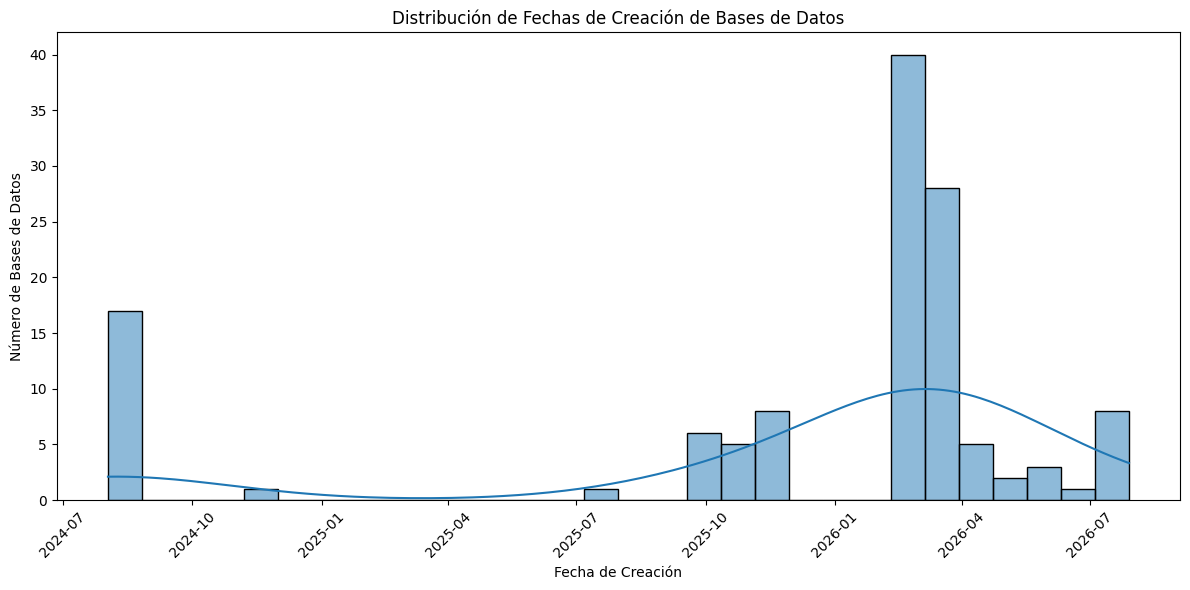

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Fecha de Creación' to datetime objects
df['Fecha de creacion'] = pd.to_datetime(df['Fecha de creacion'], errors='coerce')

# Drop rows where 'Fecha de Creación' couldn't be parsed
df_creation_dates = df.dropna(subset=['Fecha de creacion'])

# Plot the distribution of creation dates
plt.figure(figsize=(12, 6))
sns.histplot(df_creation_dates['Fecha de creacion'], bins=30, kde=True)
plt.title('Distribución de Fechas de Creación de Bases de Datos')
plt.xlabel('Fecha de Creación')
plt.ylabel('Número de Bases de Datos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ¿Se publica en oleadas o de forma constante?

Cruzando `Fecha de creacion` con `Grupos`, se revisa si ciertas áreas temáticas concentran su publicación en periodos específicos (oleadas ligadas a algún proyecto o mandato) o si publican de forma más constante en el tiempo. Se usan los 5 grupos más frecuentes; el resto se agrupa como `Otros`.

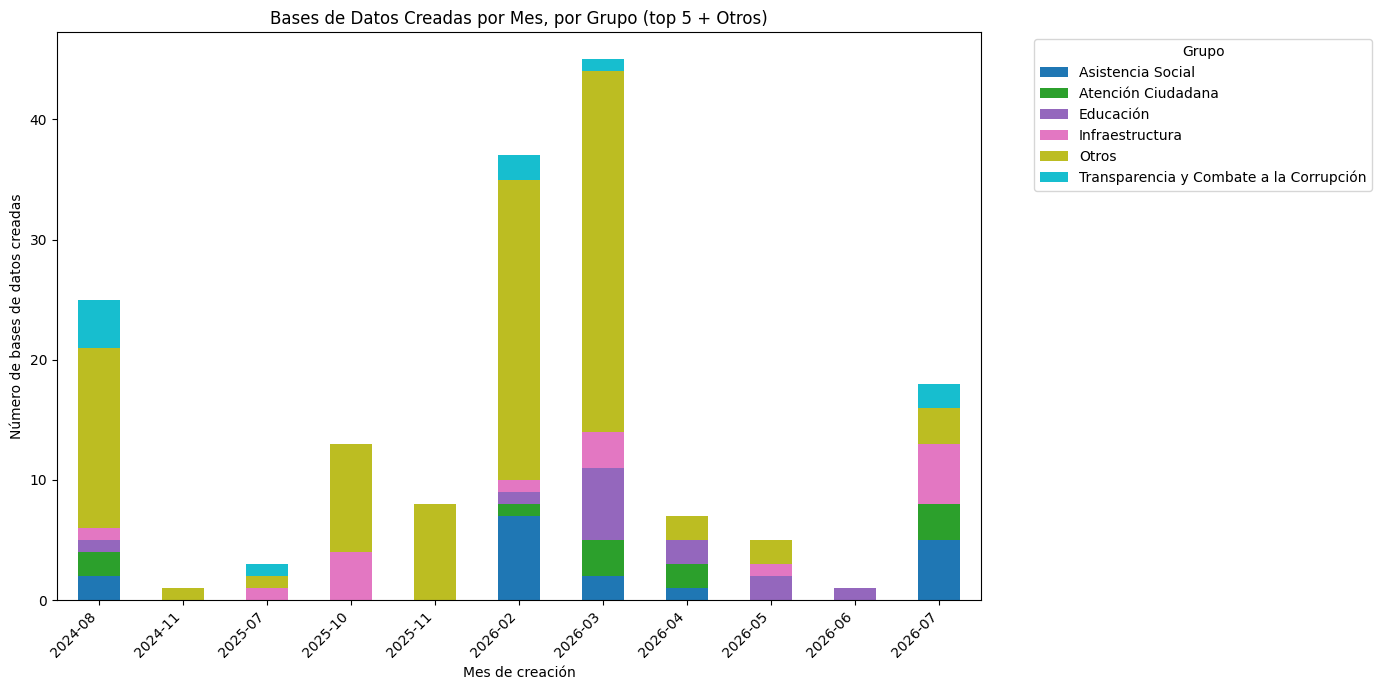

Meses con más bases de datos creadas:
 mes_creacion
2026-03    45
2026-02    37
2024-08    25
dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Expandir 'Grupos' (una base puede pertenecer a varios) y quedarnos con el mes de creación
df_time = df[['Nombre de la base de datos', 'Fecha de creacion', 'Grupos']].copy()
df_time = df_time.dropna(subset=['Fecha de creacion'])
df_time['Grupos'] = df_time['Grupos'].fillna('Sin grupo').astype(str).str.split(';')
df_time = df_time.explode('Grupos')
df_time['Grupos'] = df_time['Grupos'].str.strip()
df_time['mes_creacion'] = df_time['Fecha de creacion'].dt.to_period('M').astype(str)

# Quedarse solo con los 5 grupos más frecuentes; agrupar el resto como 'Otros'
top_groups = df['Grupos'].dropna().astype(str).str.split(';').explode().str.strip().value_counts().head(5).index
df_time['Grupo_agrupado'] = df_time['Grupos'].where(df_time['Grupos'].isin(top_groups), 'Otros')

pivot_time = df_time.pivot_table(
    index='mes_creacion', columns='Grupo_agrupado',
    values='Nombre de la base de datos', aggfunc='nunique', fill_value=0
).sort_index()

pivot_time.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab10')
plt.title('Bases de Datos Creadas por Mes, por Grupo (top 5 + Otros)')
plt.xlabel('Mes de creación')
plt.ylabel('Número de bases de datos creadas')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

picos = pivot_time.sum(axis=1).sort_values(ascending=False).head(3)
print("Meses con más bases de datos creadas:\n", picos)

### Organizaciones más comunes

Las 10 organizaciones más comunes son:
 Organizacion de origen
Secretaría de Administración                            8
Secretaría de Igualdad e Inclusión                      7
Instituto de la Vivienda                                6
Secretaría de Participación Ciudadana                   5
Secretaría de Salud                                     4
Secretaría de Educación del Estado de Nuevo León        4
Instituto de Movilidad y Accesibilidad                  4
Servicios de Agua y Drenaje de Monterrey, I.P.D.        4
Secretaría de Medio Ambiente                            3
Instituto Estatal de Cultura Física y Deporte (INDE)    3
Name: count, dtype: int64


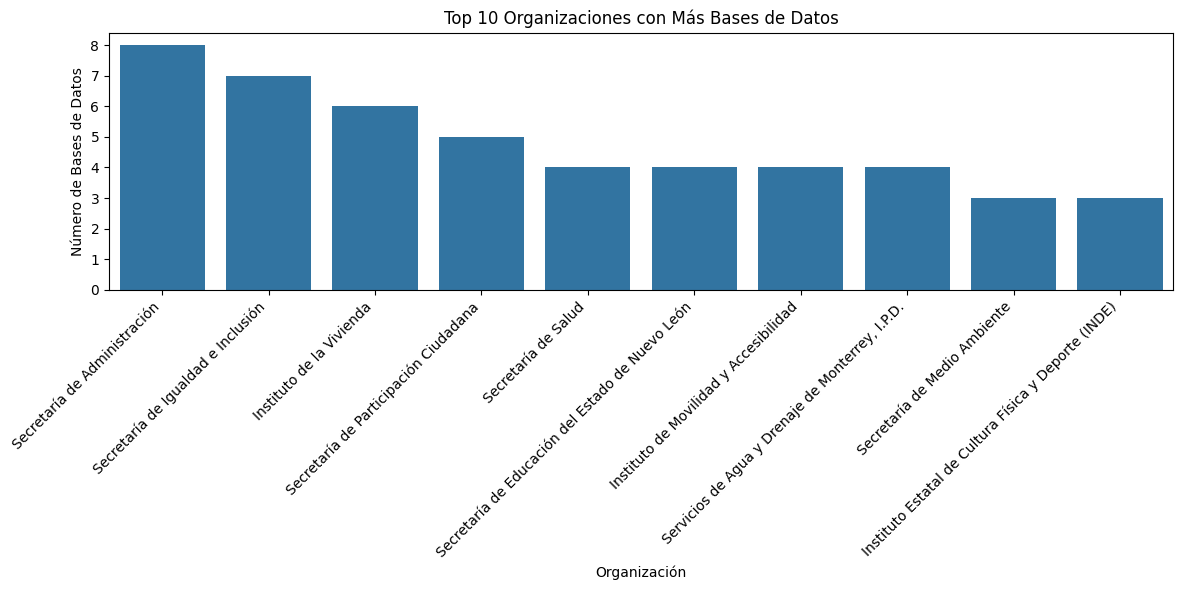

In [9]:
common_organizations = df['Organizacion de origen'].value_counts().head(10)
print("Las 10 organizaciones más comunes son:\n", common_organizations)

plt.figure(figsize=(12, 6))
sns.barplot(x=common_organizations.index, y=common_organizations.values)
plt.title('Top 10 Organizaciones con Más Bases de Datos')
plt.xlabel('Organización')
plt.ylabel('Número de Bases de Datos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Organizaciones con menos bases de datos

In [10]:
uncommon_organizations = df['Organizacion de origen'].value_counts().tail(20)
print("Las 20 organizaciones con menos bases son:\n", uncommon_organizations)

Las 20 organizaciones con menos bases son:
 Organizacion de origen
Instituto de Capacitación y Educación para el Trabajo (ICET)                                                1
Fideicomiso de Inversión y Administración (FIDEMEJORA)                                                      1
Fideicomiso Turismo Nuevo León                                                                              1
Instituto del Agua del Estado de Nuevo León                                                                 1
Fideicomiso Fondo de Fomento Agropecuario del Estado de Nuevo León                                          1
Secretaría de Turismo                                                                                       1
Fideicomiso FIDEURB (BP6823)                                                                                1
Colegio Militarizado "General Mariano Escobedo"                                                             1
Universidad de Ciencias de la Seguridad              

### Etiquetas más comunes

Las 10 etiquetas más comunes (columna: 'Etiquetas') son:
 Etiquetas
evaluacion gobernador como vamos    19
servicios                           18
transparencia                        9
programas                            7
administración                       6
participación ciudadana              6
administracion                       6
movilidad                            6
vivienda                             5
salud                                5
Name: count, dtype: int64


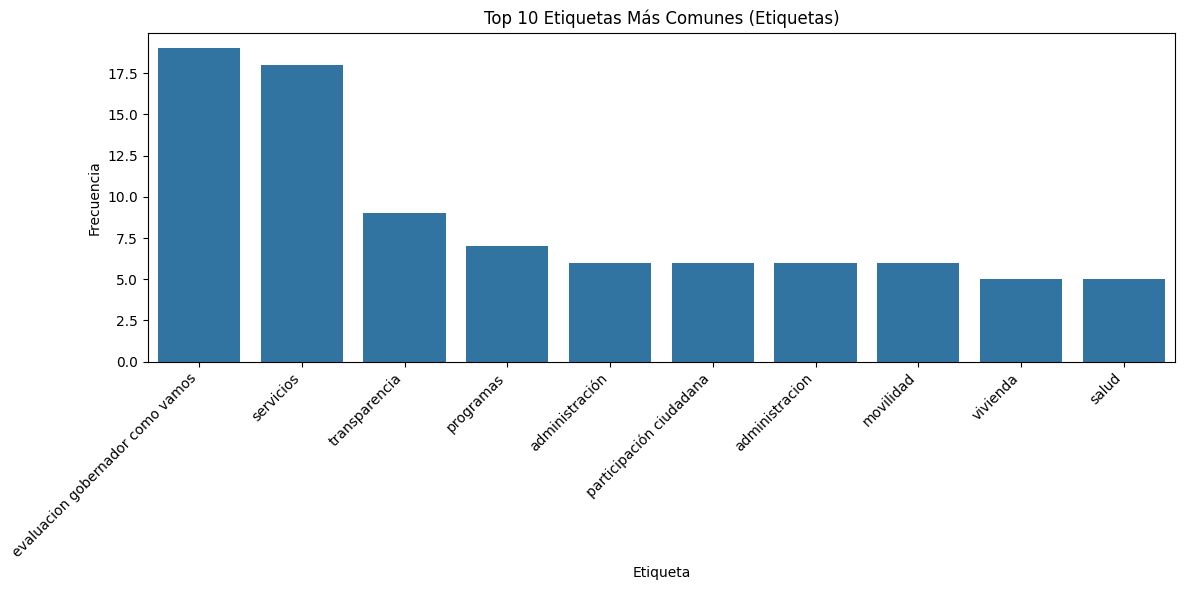

In [11]:
# Assuming 'Etiquetas' or 'Palabras Clave' is the column for tags
# If a different column contains tags, please specify.
# For now, let's look for a column that seems like it could contain tags

try:
    # Check for common tag-like column names
    tag_column = None
    for col in ['Etiquetas']:
        if col in df.columns:
            tag_column = col
            break

    if tag_column:
        # Split tags by semicolon, strip whitespace, and convert to lowercase
        all_tags = df[tag_column].dropna().astype(str).str.split(';').explode().str.strip().str.lower()
        common_tags = all_tags.value_counts().head(10)
        print(f"Las 10 etiquetas más comunes (columna: '{tag_column}') son:\n", common_tags)

        plt.figure(figsize=(12, 6))
        sns.barplot(x=common_tags.index, y=common_tags.values)
        plt.title(f'Top 10 Etiquetas Más Comunes ({tag_column})')
        plt.xlabel('Etiqueta')
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontró una columna obvia de etiquetas como 'Etiquetas', 'Palabras Clave', 'Tags' o 'Temas'. Por favor, especifique la columna correcta.")
except Exception as e:
    print(f"Ocurrió un error al procesar las etiquetas: {e}")
    print("Por favor, asegúrese de que la columna de etiquetas existe y tiene el formato esperado.")

### Frecuencia de Todas las Etiquetas

In [12]:
# Contar la frecuencia de todas las etiquetas procesadas
all_tags_counts = all_tags.value_counts()

print("Tabla de Frecuencia de Etiquetas:\n")
display(all_tags_counts.to_frame(name='Frecuencia'))

Tabla de Frecuencia de Etiquetas:



,Frecuencia
Etiquetas,
evaluacion gobernador como vamos,19
servicios,18
transparencia,9
programas,7
administración,6
...,...
tipo de violencia,1
primera infancia,1
paradas,1


El equipo reporta que el banco oficial de etiquetas del portal (revisado directamente en el panel administrativo, no en este CSV) contenía únicamente 29 etiquetas registradas al momento de la consulta (actualización enero 2025), algunas incluso sin uso. Sin embargo, el análisis anterior encuentra **146 valores de etiqueta distintos** realmente escritos en las bases de datos. Esto confirma que no existe "un banco" del que los autores seleccionen etiquetas al publicar: cada quien escribe las suyas libremente (con variantes como `administracion`/`administración`, o etiquetas hiperespecíficas de una sola base de datos), lo que vuelve el campo `Etiquetas` poco útil para filtrar o clasificar de forma consistente.

### Bases de datos por grupo

Bases de datos por grupo:
 Grupos
Asistencia Social                             17
Infraestructura                               16
Educación                                     13
Atención Ciudadana                            11
Transparencia y Combate a la Corrupción       10
Administración y Finanzas                     10
Participación                                  8
Medio Ambiente                                 8
Arte y Cultura                                 7
Movilidad y Transporte                         7
Perspectiva de Género e Interseccionalidad     6
Seguridad                                      6
Turismo                                        6
Salud                                          4
Deportes                                       4
Agroalimentario                                3
Administración                                 2
Name: count, dtype: int64


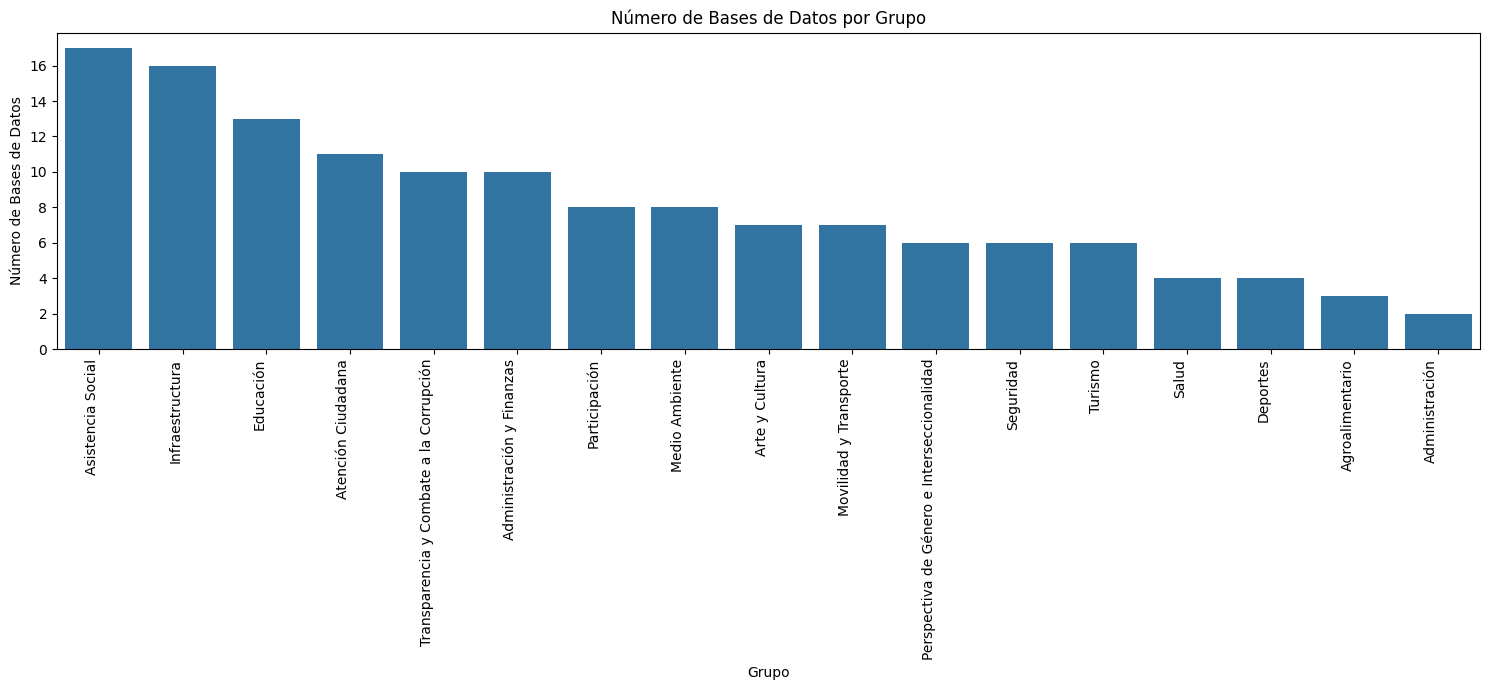

In [13]:
all_groups = df['Grupos'].dropna().astype(str).str.split(';').explode().str.strip()
common_groups = all_groups.value_counts()
print("Bases de datos por grupo:\n", common_groups)

plt.figure(figsize=(15, 7))
sns.barplot(x=common_groups.index, y=common_groups.values)
plt.title('Número de Bases de Datos por Grupo')
plt.xlabel('Grupo')
plt.ylabel('Número de Bases de Datos')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### ¿Cuántas bases de datos no tienen diccionario de variables y cuáles son?

In [14]:
no_dict_df = df[df['Diccionario (Si/No)'] == 'No']
num_no_dict = len(no_dict_df)
print(f"Hay {num_no_dict} bases de datos que no tienen diccionario de variables.")
print("Nombres de las bases de datos sin diccionario:\n")
for name in no_dict_df['Nombre de la base de datos']:
    print(f"- {name}")

Hay 2 bases de datos que no tienen diccionario de variables.
Nombres de las bases de datos sin diccionario:

- Contrataciones Abiertas de la Dirección General de Adquisiciones y Servicios
- PROCESO EXTINCIÓN DEL FIDEICOMISO FOMENTO METROPOLITANO DE MONTERREY (FOMERREY)


### ¿Cuántas bases de datos no fueron actualizadas?

Se exploran dos criterios distintos y complementarios:
1.  **A continuación:** bases con `'Ultima actualizacion'` faltante, o con una fecha de actualización anterior a su propia fecha de creación (inconsistencia de captura).
2.  **Más abajo:** bases cuya *próxima* actualización esperada (calculada a partir de su periodicidad declarada) ya pasó respecto a una fecha de referencia fija, es decir, que están vencidas según su propio calendario de publicación.

In [15]:
# Convert 'Fecha de Actualización' to datetime objects
df['Ultima actualizacion'] = pd.to_datetime(df['Ultima actualizacion'], errors='coerce')

# A database is considered 'not updated' if 'Fecha de Actualización' is null/NaT
# or if it's older than its 'Fecha de Creación'.
# First, count those with missing 'Fecha de Actualización'
not_updated_missing = df['Ultima actualizacion'].isnull().sum()

# Then, consider those where update date is older than creation date
# Ensure 'Fecha de Creación' is also datetime (already done in a previous cell)
not_updated_older = df[(df['Ultima actualizacion'].notnull()) & (df['Ultima actualizacion'] < df['Fecha de creacion'])]

print(f"Bases de datos con 'Fecha de Actualización' faltante: {not_updated_missing}")
print(f"Bases de datos con 'Fecha de Actualización' anterior a la 'Fecha de Creación': {len(not_updated_older)}")
print(f"Total de bases de datos potencialmente 'no actualizadas' (faltantes o con fecha antigua): {not_updated_missing + len(not_updated_older)}")

print("Nombres de las bases de datos con 'Fecha de Actualización' faltante:\n")
for name in df[df['Ultima actualizacion'].isnull()]['Nombre de la base de datos']:
    print(f"- {name}")

print("\nNombres de las bases de datos con 'Fecha de Actualización' anterior a la 'Fecha de Creación':\n")
for name in not_updated_older['Nombre de la base de datos']:
    print(f"- {name}")

Bases de datos con 'Fecha de Actualización' faltante: 0
Bases de datos con 'Fecha de Actualización' anterior a la 'Fecha de Creación': 0
Total de bases de datos potencialmente 'no actualizadas' (faltantes o con fecha antigua): 0
Nombres de las bases de datos con 'Fecha de Actualización' faltante:


Nombres de las bases de datos con 'Fecha de Actualización' anterior a la 'Fecha de Creación':



Antes de calcular vigencias, se estandariza `'Periodo de actualizacion'` (minúsculas) y se corrige el único valor claramente mal capturado, `'mayo 2026'` — una fecha metida en un campo que debería contener una periodicidad (mensual, anual, etc.). **Este es en sí mismo un hallazgo de calidad de la plataforma**: al menos un formulario de publicación permitió capturar un valor fuera de catálogo en ese campo. Se reemplaza por `'anual'` como supuesto razonable, pero lo ideal sería que el equipo de GeoStats confirme con la fuente original cuál era la periodicidad real.

In [16]:
unique_periods = df['Periodo de actualizacion'].unique()
print("Valores únicos en 'Periodo de actualizacion':")
for period in unique_periods:
    print(f"- {period}")

Valores únicos en 'Periodo de actualizacion':
- Cuatrimestral
- mensual
- Mensual
- Semanal
- Anual
- Semestral
- Trimestral
- mayo 2026
- nan
- anual
- trimestral
- Bimestral
- Documento Único


In [17]:
df['Periodo de actualizacion'] = df['Periodo de actualizacion'].astype(str).str.lower().replace('mayo 2026', 'anual')

print("Valores únicos actualizados en 'Periodo de actualizacion':")
for period in df['Periodo de actualizacion'].unique():
    print(f"- {period}")

Valores únicos actualizados en 'Periodo de actualizacion':
- cuatrimestral
- mensual
- semanal
- anual
- semestral
- trimestral
- nan
- bimestral
- documento único


Con los periodos ya estandarizados, se estima la *próxima fecha de actualización esperada* de cada base de datos (última actualización + su periodicidad) y se compara contra una **fecha de referencia fija: el 12 de septiembre de 2026**. Se usa esta fecha fija — en vez de `pd.Timestamp.now()`, la fecha del día en que se corre el notebook — para que el resultado sea reproducible: cualquier persona que ejecute este notebook, hoy o en el futuro, obtiene el mismo diagnóstico de cuáles bases de datos estaban vencidas en ese punto en el tiempo, en vez de un número que cambia cada día.

In [18]:
from datetime import datetime
import pandas as pd

# Ensure 'Ultima actualizacion' is datetime (already done in a previous cell, but good practice)
df['Ultima actualizacion'] = pd.to_datetime(df['Ultima actualizacion'], errors='coerce')

# Fecha de referencia FIJA (en vez de pd.Timestamp.now()) para que el análisis sea reproducible.
# Se usa el 12 de septiembre de 2026 como punto de corte para evaluar si cada base de datos
# ya debió actualizarse según su periodicidad declarada.
FECHA_REFERENCIA = pd.Timestamp('2026-09-12')

def calculate_expected_next_update(row):
    last_update = row['Ultima actualizacion']
    period = row['Periodo de actualizacion'] # This column is already lowercased and standardized

    if pd.isna(last_update) or pd.isna(period) or period == 'documento único':
        return pd.NaT # Cannot determine next update

    if period == 'cuatrimestral':
        return last_update + pd.DateOffset(months=4)
    elif period == 'mensual':
        return last_update + pd.DateOffset(months=1)
    elif period == 'semanal':
        return last_update + pd.Timedelta(weeks=1)
    elif period == 'anual':
        return last_update + pd.DateOffset(years=1)
    elif period == 'semestral':
        return last_update + pd.DateOffset(months=6)
    elif period == 'trimestral':
        return last_update + pd.DateOffset(months=3)
    elif period == 'bimestral':
        return last_update + pd.DateOffset(months=2)
    else:
        return pd.NaT # Handle any unmapped periods

# Apply the function to create a new column for expected next update
df['expected_next_update'] = df.apply(calculate_expected_next_update, axis=1)

# Bandera de 'vencida': ya pasó su próxima actualización esperada respecto a FECHA_REFERENCIA.
# Se deja como columna en df (no se borra al final) porque se reutiliza en la siguiente celda
# para el análisis de cumplimiento por grupo y organización.
df['vencida'] = (df['expected_next_update'].notna()) & (df['expected_next_update'] < FECHA_REFERENCIA)

past_due_updates = df[df['vencida']]
num_past_due_updates = len(past_due_updates)

print(f"Con fecha de referencia {FECHA_REFERENCIA.date()}, había {num_past_due_updates} bases de datos "
      f"cuya fecha de actualización esperada ya había pasado y estaba pendiente.")

if num_past_due_updates > 0:
    print("Nombres de las bases de datos con actualización pendiente:")
    for name in past_due_updates['Nombre de la base de datos']:
        print(f"- {name}")
else:
    print("Todas las bases de datos estaban al día según su último periodo de actualización definido, "
          "o no tienen un periodo de actualización que permita calcular una próxima fecha.")

Con fecha de referencia 2026-09-12, había 39 bases de datos cuya fecha de actualización esperada ya había pasado y estaba pendiente.
Nombres de las bases de datos con actualización pendiente:
- Contrataciones Abiertas de la Dirección General de Adquisiciones y Servicios
- Atenciones del 070 por canal
- Servicios para el campo
- Prepa Abierta
- Solicitud de informacion Instituto Registral y Catastral
- Residuos Sólidos Urbanos
- Solicitudes de acceso a la información recibidas en la Administración Pública Estatal
- Registros Programa Impulso NAFIN+Nuevo León
- Nuevo León al Día
- Programación infantil en canal 28.1 y 28.2 marzo
- Saldos de rendimientos de aportación del Fideicomiso
- Unidades de Transporte Público
- Solicitudes de Acceso a la Información
- Solicitudes de Acceso a la Información del Fondo de Fomento Agropecuario del Estado de Nuevo León
- Planteles Colegio Militarizado "General Mariano Escobedo" del Estado de Nuevo León
- Solicitudes de Acceso a la información recibidas 

#### Cumplimiento de actualización por grupo

Usando la fecha de referencia fija (12 de septiembre de 2026) y el indicador `vencida` calculado arriba, se resume qué proporción de bases de datos de cada `Grupo` estaban vencidas en esa fecha (excluyendo bases sin una periodicidad definida, para no penalizarlas injustamente). Esta es una vista pensada directamente para el futuro dashboard: permite priorizar seguimiento por área temática.

Bases de datos vencidas por grupo al 2026-09-12 (solo grupos con periodicidad definida):



,vencidas,total_evaluables,% vencidas
Grupos,,,
Movilidad y Transporte,6,7,85.7
Seguridad,3,6,50.0
Transparencia y Combate a la Corrupción,4,10,40.0
Participación,3,8,37.5
Agroalimentario,1,3,33.3
Administración y Finanzas,3,10,30.0
Arte y Cultura,2,7,28.6
Medio Ambiente,2,8,25.0
Educación,3,13,23.1


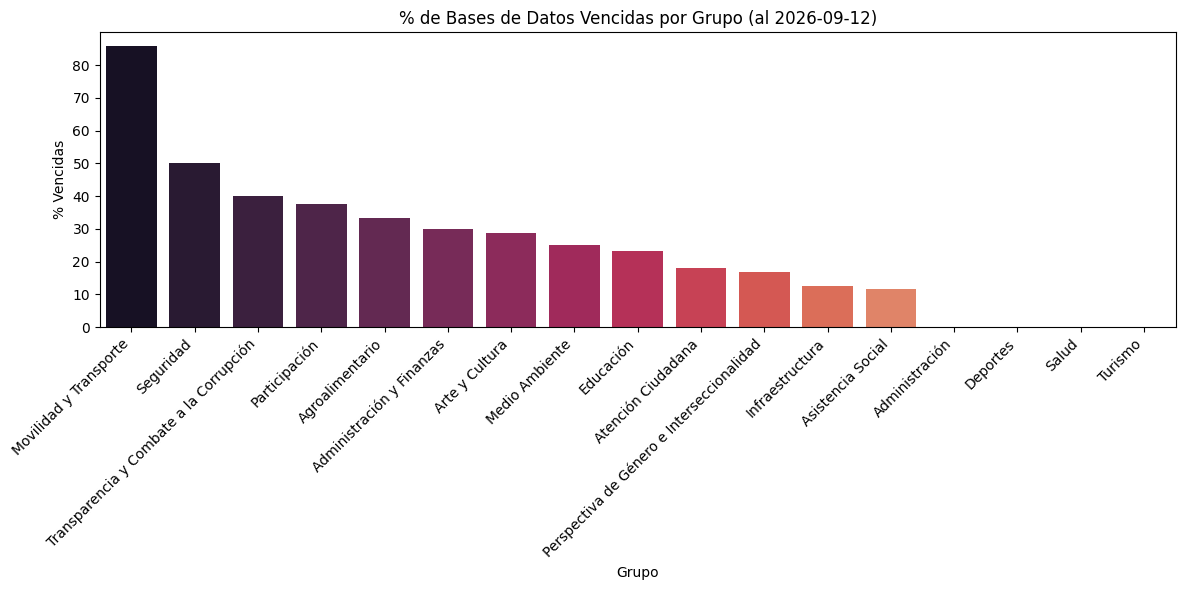

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Expandir 'Grupos' (puede haber varios por base de datos) y unir con el indicador de vencida
df_groups_vencida = df[['Nombre de la base de datos', 'Grupos', 'Organizacion de origen', 'vencida', 'Periodo de actualizacion']].copy()
df_groups_vencida['Grupos'] = df_groups_vencida['Grupos'].dropna().astype(str).str.split(';')
df_groups_vencida = df_groups_vencida.explode('Grupos')
df_groups_vencida['Grupos'] = df_groups_vencida['Grupos'].str.strip()

# Excluir bases sin una periodicidad que permita calcular vigencia (p. ej. 'documento único' o nulo)
periodos_evaluables = ['mensual', 'anual', 'semestral', 'trimestral', 'cuatrimestral', 'semanal', 'bimestral']
df_groups_vencida_valid = df_groups_vencida[df_groups_vencida['Periodo de actualizacion'].isin(periodos_evaluables)]

cumplimiento_grupo = (
    df_groups_vencida_valid.groupby('Grupos')['vencida']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'vencidas', 'count': 'total_evaluables'})
)
cumplimiento_grupo['% vencidas'] = (cumplimiento_grupo['vencidas'] / cumplimiento_grupo['total_evaluables'] * 100).round(1)
cumplimiento_grupo = cumplimiento_grupo.sort_values('% vencidas', ascending=False)

print(f"Bases de datos vencidas por grupo al {FECHA_REFERENCIA.date()} (solo grupos con periodicidad definida):\n")
display(cumplimiento_grupo)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=cumplimiento_grupo.index,
    y=cumplimiento_grupo['% vencidas'],
    hue=cumplimiento_grupo.index,
    palette='rocket',
    legend=False,
)
plt.title(f'% de Bases de Datos Vencidas por Grupo (al {FECHA_REFERENCIA.date()})')
plt.xlabel('Grupo')
plt.ylabel('% Vencidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Limpieza de columnas temporales que ya no se necesitan más adelante
df.drop(columns=['expected_next_update', 'vencida'], errors='ignore', inplace=True)

### Encontrar la cantidad de valores nulos en la base de datos y la causa de su falta

In [20]:
null_counts = df.isnull().sum()
print("Cantidad de valores nulos por columna:\n", null_counts[null_counts > 0])

print("\nLas causas de la falta de valores son variadas y pueden incluir:")
print("- **Datos no registrados:** Ciertos campos simplemente no fueron completados al momento de la entrada de datos.")
print("- **Información no aplicable:** Para algunas bases de datos, ciertos atributos pueden no ser relevantes.")
print("- **Errores de extracción o carga:** Problemas durante la recolección o importación de datos pueden generar valores nulos.")
print("- **Privacidad o confidencialidad:** Cierta información podría haber sido omitida intencionalmente por razones de privacidad.")
print("- **Esquema de datos inconsistente:** La estructura de los datos puede variar entre diferentes entradas, llevando a campos vacíos.")

Cantidad de valores nulos por columna:
 Fuente                      110
Mantenedor                    3
Periodo de actualizacion      5
Proxima actualizacion         8
Etiquetas                     4
Grupos                       38
dtype: int64

Las causas de la falta de valores son variadas y pueden incluir:
- **Datos no registrados:** Ciertos campos simplemente no fueron completados al momento de la entrada de datos.
- **Información no aplicable:** Para algunas bases de datos, ciertos atributos pueden no ser relevantes.
- **Errores de extracción o carga:** Problemas durante la recolección o importación de datos pueden generar valores nulos.
- **Privacidad o confidencialidad:** Cierta información podría haber sido omitida intencionalmente por razones de privacidad.
- **Esquema de datos inconsistente:** La estructura de los datos puede variar entre diferentes entradas, llevando a campos vacíos.


### Visualización Consolidada de Valores Nulos y No Nulos


--- Conteo de Valores Nulos por Columna ---
Fuente                      110
Mantenedor                    3
Periodo de actualizacion      5
Proxima actualizacion         8
Etiquetas                     4
Grupos                       38
dtype: int64

--- Porcentaje de Valores Nulos por Columna ---
Fuente                      65.5%
Mantenedor                   1.8%
Periodo de actualizacion     3.0%
Proxima actualizacion        4.8%
Etiquetas                    2.4%
Grupos                      22.6%
dtype: str


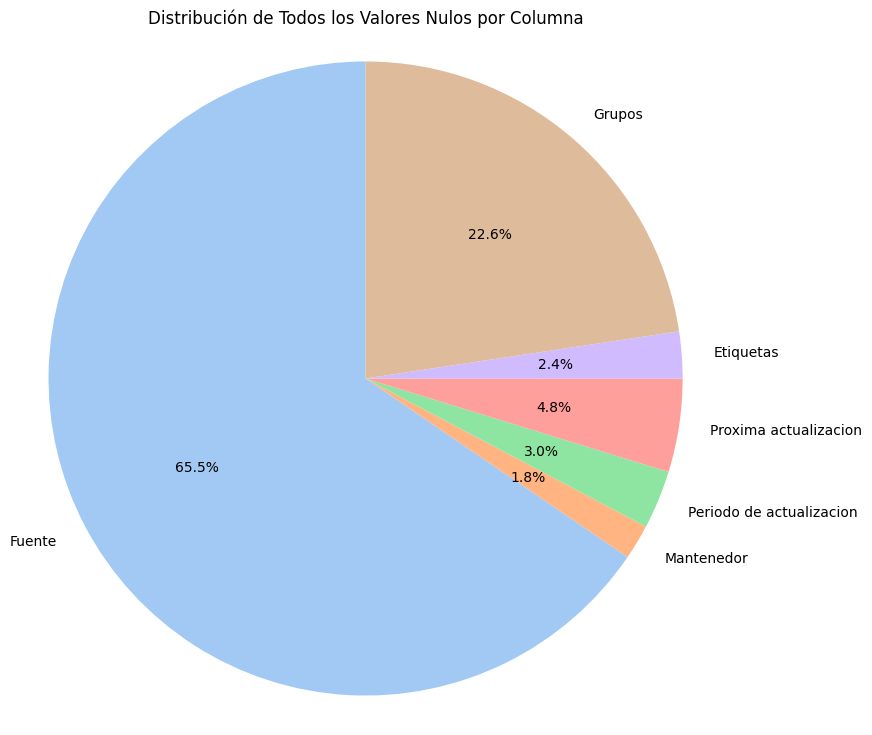

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcular los valores nulos por columna
null_counts_per_column = df.isnull().sum()

# Filtrar solo las columnas que tienen valores nulos
columns_with_nulls = null_counts_per_column[null_counts_per_column > 0]

# --- Gráfica de Pastel: Distribución de Valores Nulos por Columna ---

if not columns_with_nulls.empty:
    print("\n--- Conteo de Valores Nulos por Columna ---")
    print(columns_with_nulls)

    # Calculate percentages
    total_nulls = columns_with_nulls.sum()
    if total_nulls > 0:
        percentages = (columns_with_nulls / total_nulls) * 100
        print("\n--- Porcentaje de Valores Nulos por Columna ---")
        print(percentages.apply(lambda x: f'{x:.1f}%'))
    else:
        print("No hay valores nulos para calcular porcentajes.")

    plt.figure(figsize=(9, 9))
    plt.pie(columns_with_nulls, labels=columns_with_nulls.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
    plt.title('Distribución de Todos los Valores Nulos por Columna')
    plt.axis('equal')
    plt.show()
else:
    print("No hay valores nulos en el DataFrame para graficar en el pastel.")

El DataFrame tiene un total de 125 filas.

--- Verificación de Suma de Nulos y No Nulos por Columna ---
Columna: 'Nombre de la base de datos' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Diccionario (Si/No)' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Fuente' -> No Nulos: 15, Nulos: 110, Suma Total: 125
Columna: 'Autor' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Mantenedor' -> No Nulos: 122, Nulos: 3, Suma Total: 125
Columna: 'Ultima actualizacion' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Fecha de creacion' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Periodo de actualizacion' -> No Nulos: 120, Nulos: 5, Suma Total: 125
Columna: 'Proxima actualizacion' -> No Nulos: 117, Nulos: 8, Suma Total: 125
Columna: 'Etiquetas' -> No Nulos: 121, Nulos: 4, Suma Total: 125
Columna: 'Organizacion de origen' -> No Nulos: 125, Nulos: 0, Suma Total: 125
Columna: 'Grupos' -> No Nulos: 87, Nulos: 38, Suma Total: 125
Columna: 'Formatos' -> No Nulos: 125, 

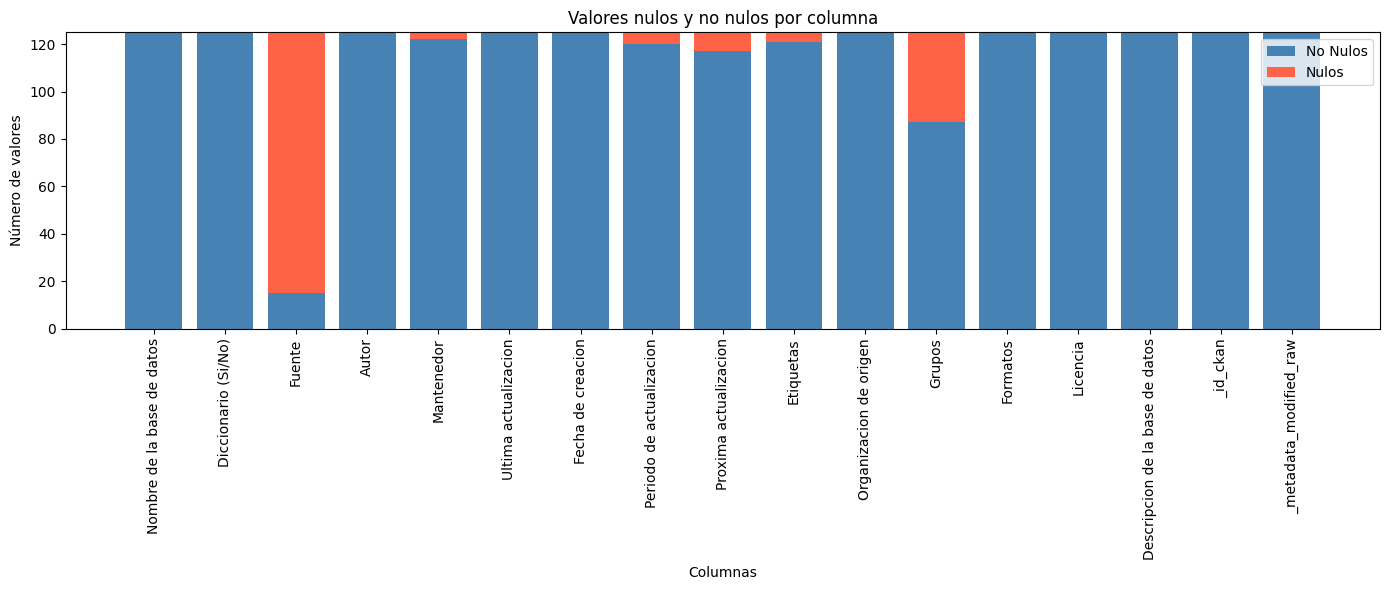

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar los datos para la gráfica de barras apilada
# Cada barra representará una columna, y estará segmentada en no nulos y nulos

# Calcular el total de filas
total_rows = len(df)
print(f"El DataFrame tiene un total de {total_rows} filas.\n")

# Crear un DataFrame para la gráfica de barras
bar_data = pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': [df[col].count() for col in df.columns],
    'Nulos': [df[col].isnull().sum() for col in df.columns]
})

print("--- Verificación de Suma de Nulos y No Nulos por Columna ---")
for index, row in bar_data.iterrows():
    columna = row['Columna']
    no_nulos = row['No Nulos']
    nulos = row['Nulos']
    suma_total = no_nulos + nulos
    print(f"Columna: '{columna}' -> No Nulos: {no_nulos}, Nulos: {nulos}, Suma Total: {suma_total}")

# Crear la gráfica
plt.figure(figsize=(14, 6))

plt.bar(
    bar_data['Columna'],
    bar_data['No Nulos'],
    label='No Nulos',
    color='steelblue'
)

plt.bar(
    bar_data['Columna'],
    bar_data['Nulos'],
    bottom=bar_data['No Nulos'],
    label='Nulos',
    color='tomato'
)

# Etiquetas y formato
plt.xlabel('Columnas')
plt.ylabel('Número de valores')
plt.title('Valores nulos y no nulos por columna')

plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

### Resumen de Valores Nulos

Como se pudo observar en los análisis anteriores:

*   **Columnas con Valores Nulos:** las columnas `Fuente`, `Mantenedor`, `Periodo de actualizacion`, `Proxima actualizacion`, `Etiquetas` y `Grupos` contienen valores nulos.
*   **`Fuente`** es la columna con el mayor porcentaje de valores nulos, representando **~65.5%** de todos los nulos encontrados en el DataFrame, seguida por `Grupos` (~22.6%).
*   **Causas Potenciales:** la presencia de valores nulos puede deberse a:
    *   Datos no registrados o faltantes al momento de la entrada.
    *   Información no aplicable para ciertas bases de datos.
    *   Errores durante la extracción o carga de datos.
    *   Omisión intencional por razones de privacidad o confidencialidad.
    *   Inconsistencias en el esquema de datos.

Es crucial considerar estos nulos para futuros análisis o limpieza de datos, decidiendo si imputarlos, ignorarlos o eliminarlos según el contexto de cada columna.

### Distribución de Formatos de Datos

Distribución de Formatos de Datos:
 Formatos
CSV          122
JSON, URL      1
TXT            1
CSV, XLSX      1
Name: count, dtype: int64


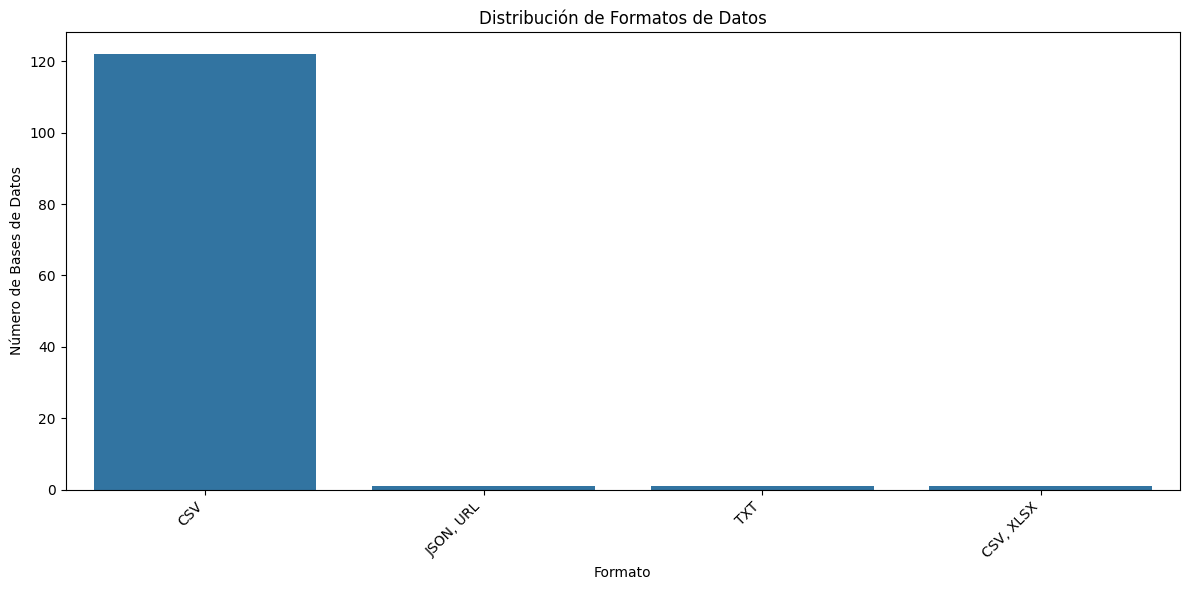

In [23]:
# Contar la frecuencia de cada formato
format_counts = df['Formatos'].value_counts()

print("Distribución de Formatos de Datos:\n", format_counts)

# Visualizar la distribución de formatos
plt.figure(figsize=(12, 6))
sns.barplot(x=format_counts.index, y=format_counts.values)
plt.title('Distribución de Formatos de Datos')
plt.xlabel('Formato')
plt.ylabel('Número de Bases de Datos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis de Licencias

Distribución de Licencias:
 Licencia
Open Data Commons Attribution License    103
Creative Commons Attribution              19
Sin licencia especificada                  3
Name: count, dtype: int64


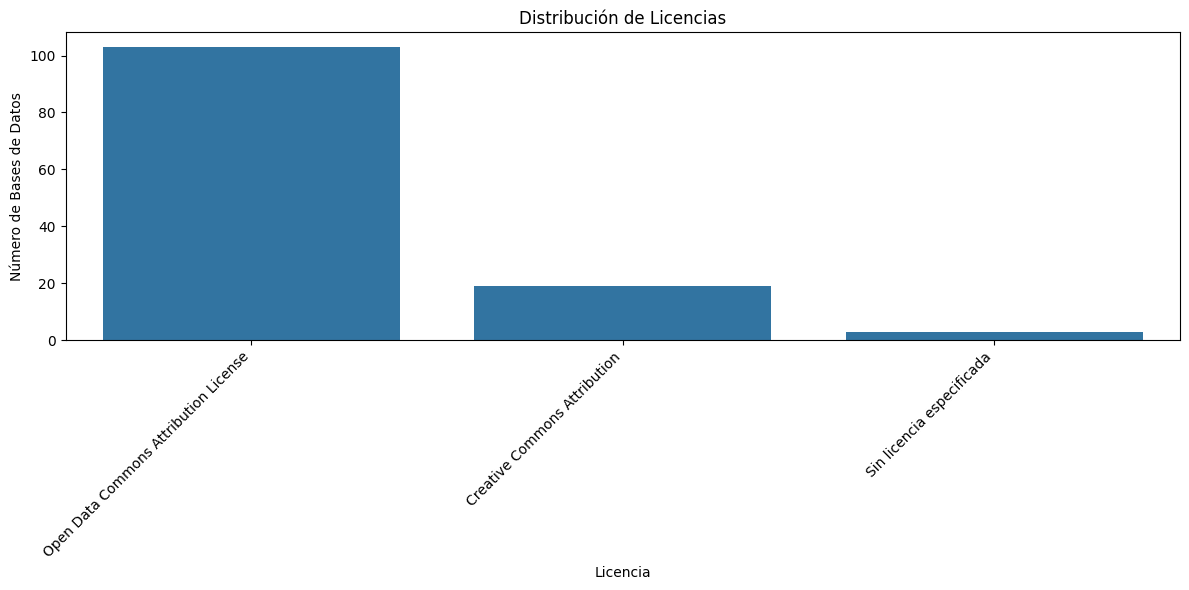

In [24]:
# Contar la frecuencia de cada tipo de licencia
license_counts = df['Licencia'].value_counts()

print("Distribución de Licencias:\n", license_counts)

# Visualizar la distribución de licencias
plt.figure(figsize=(12, 6))
sns.barplot(x=license_counts.index, y=license_counts.values)
plt.title('Distribución de Licencias')
plt.xlabel('Licencia')
plt.ylabel('Número de Bases de Datos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Completitud de las descripciones

Una descripción vacía o demasiado corta dificulta que alguien entienda de qué trata una base de datos sin tener que abrir el archivo. Se mide la longitud, en palabras, de `Descripcion de la base de datos` para detectar los casos más pobres.

Bases de datos sin descripción: 0
Bases de datos con descripción de 5 palabras o menos: 1


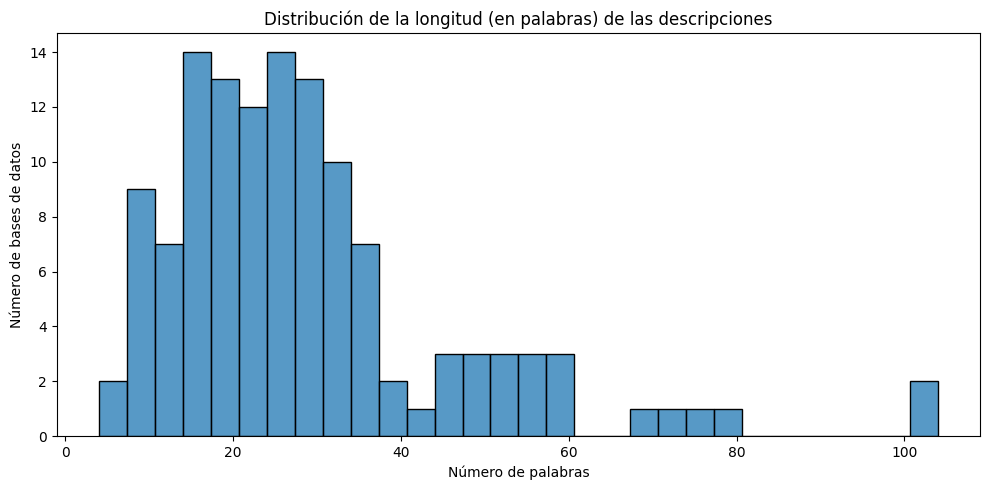


Bases de datos con descripción de 5 palabras o menos:
- Solicitudes de Información (4 palabra(s))


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df['desc_word_count'] = df['Descripcion de la base de datos'].fillna('').astype(str).str.split().str.len()

sin_descripcion = df[df['desc_word_count'] == 0]
desc_corta = df[(df['desc_word_count'] > 0) & (df['desc_word_count'] <= 5)]

print(f"Bases de datos sin descripción: {len(sin_descripcion)}")
print(f"Bases de datos con descripción de 5 palabras o menos: {len(desc_corta)}")

plt.figure(figsize=(10, 5))
sns.histplot(df['desc_word_count'], bins=30)
plt.title('Distribución de la longitud (en palabras) de las descripciones')
plt.xlabel('Número de palabras')
plt.ylabel('Número de bases de datos')
plt.tight_layout()
plt.show()

if not sin_descripcion.empty:
    print("\nBases de datos sin descripción:")
    for name in sin_descripcion['Nombre de la base de datos']:
        print(f"- {name}")

if not desc_corta.empty:
    print("\nBases de datos con descripción de 5 palabras o menos:")
    for name, wc in zip(desc_corta['Nombre de la base de datos'], desc_corta['desc_word_count']):
        print(f"- {name} ({wc} palabra(s))")

df.drop(columns=['desc_word_count'], inplace=True)

### Puntaje de completitud por base de datos (0-100)

Se combina en un solo puntaje, de 0 a 100, cinco señales de calidad ya calculadas en las secciones anteriores (20 puntos cada una): tener diccionario de variables, tener al menos una etiqueta, pertenecer a algún grupo, tener una descripción de más de 5 palabras, y estar vigente según su periodicidad (con la misma fecha de referencia fija usada arriba). Es un indicador pensado para usarse tal cual como columna filtrable/ordenable en el futuro dashboard.

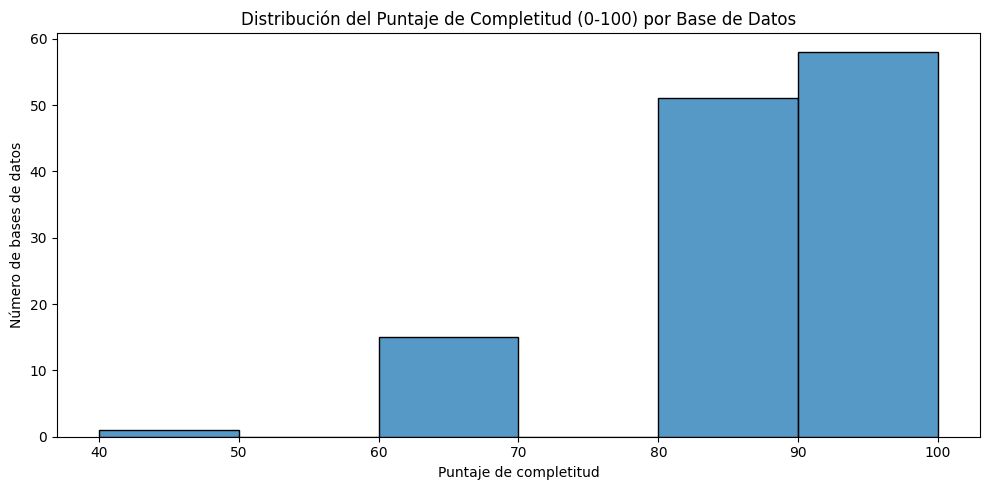

Bases de datos con menor puntaje de completitud (peor calidad general):



,Nombre de la base de datos,score_completitud,tiene_diccionario,tiene_etiquetas,tiene_grupo,descripcion_decente,vigente
50,Solicitudes de Información,40,1,0,0,0,1
3,Contrataciones Abiertas de la Dirección Genera...,60,0,1,1,1,0
56,Registros Programa Impulso NAFIN+Nuevo León,60,1,1,0,1,0
55,PROCESO EXTINCIÓN DEL FIDEICOMISO FOMENTO METR...,60,0,1,0,1,1
63,Saldos de rendimientos de aportación del Fidei...,60,1,1,0,1,0
98,Declaraciones oficiales de la Oficina Ejecutiva,60,1,1,0,1,0
110,Paradas Oficiales STC Metrorrey,60,1,0,1,1,0
107,Rutas por Empresa STC Metrorrey,60,1,1,0,1,0
86,Tramites y Servicios a Pequeñas y Medianas Emp...,60,1,1,0,1,0
90,Maestrías ofertadas por el IIIEPE,60,1,1,0,1,0


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

score_df = df[['Nombre de la base de datos', 'Organizacion de origen', 'Mantenedor',
               'Diccionario (Si/No)', 'Etiquetas', 'Grupos',
               'Descripcion de la base de datos', 'Ultima actualizacion', 'Periodo de actualizacion']].copy()

score_df['tiene_diccionario'] = (score_df['Diccionario (Si/No)'] == 'Si').astype(int)
score_df['tiene_etiquetas'] = score_df['Etiquetas'].notna().astype(int)
score_df['tiene_grupo'] = score_df['Grupos'].notna().astype(int)

desc_words = score_df['Descripcion de la base de datos'].fillna('').astype(str).str.split().str.len()
score_df['descripcion_decente'] = (desc_words > 5).astype(int)

# Reutiliza la misma lógica de vigencia (función y fecha de referencia fija definidas más arriba)
expected_next_update = score_df.apply(calculate_expected_next_update, axis=1)
score_df['vigente'] = (~((expected_next_update.notna()) & (expected_next_update < FECHA_REFERENCIA))).astype(int)
score_df['expected_next_update'] = expected_next_update

componentes = ['tiene_diccionario', 'tiene_etiquetas', 'tiene_grupo', 'descripcion_decente', 'vigente']
score_df['score_completitud'] = score_df[componentes].sum(axis=1) * 20

plt.figure(figsize=(10, 5))
sns.histplot(score_df['score_completitud'], bins=6)
plt.title('Distribución del Puntaje de Completitud (0-100) por Base de Datos')
plt.xlabel('Puntaje de completitud')
plt.ylabel('Número de bases de datos')
plt.tight_layout()
plt.show()

print("Bases de datos con menor puntaje de completitud (peor calidad general):\n")
display(
    score_df.sort_values('score_completitud')
    .head(10)[['Nombre de la base de datos', 'score_completitud'] + componentes]
)

### Desglose del score por base de datos individual

Los puntajes agregados (por organización, por grupo) son útiles para comparar, pero para dar seguimiento a una base de datos en particular hace falta responder algo más concreto: *¿por qué esta base de datos obtuvo el puntaje que obtuvo?* La función `explicar_score` recibe el nombre (o parte del nombre) de una base de datos y regresa el detalle de los 5 criterios que la componen — cuáles cumple, cuáles no, y por qué. Es la misma lógica que se usa en el dashboard, en la sección *Análisis por base de datos*.

In [27]:
def explicar_score(nombre_base):
    """Devuelve un DataFrame con el desglose del score de completitud (0-100)
    de una base de datos, criterio por criterio. Busca por coincidencia parcial
    de nombre (sin distinguir mayúsculas/minúsculas)."""
    coincidencias = score_df[score_df['Nombre de la base de datos'].str.contains(nombre_base, case=False, na=False)]

    if coincidencias.empty:
        print(f"No se encontró ninguna base de datos que coincida con '{nombre_base}'.")
        return None
    if len(coincidencias) > 1:
        print(f"{len(coincidencias)} coincidencias para '{nombre_base}', mostrando la primera:")
        for n in coincidencias['Nombre de la base de datos']:
            print(f"  - {n}")

    fila = coincidencias.iloc[0]
    num_palabras = len(str(fila['Descripcion de la base de datos'] or '').split())
    prox = fila['expected_next_update']
    prox_txt = prox.strftime('%d/%m/%Y') if pd.notna(prox) else 'sin periodicidad definida'

    criterios = [
        ('Tiene diccionario de variables', fila['tiene_diccionario'],
         f"Campo 'Diccionario (Si/No)' = '{fila['Diccionario (Si/No)']}'"),
        ('Tiene etiquetas', fila['tiene_etiquetas'],
         'Sin etiquetas asignadas' if not fila['tiene_etiquetas'] else f"Etiquetas: {fila['Etiquetas']}"),
        ('Tiene grupo o categoría', fila['tiene_grupo'],
         'Sin grupo asignado' if not fila['tiene_grupo'] else f"Grupos: {fila['Grupos']}"),
        ('Descripción completa (> 5 palabras)', fila['descripcion_decente'],
         f"{num_palabras} palabra(s) en la descripción"),
        ('Vigente (no vencida)', fila['vigente'],
         f"Próxima actualización esperada: {prox_txt} (ref. {FECHA_REFERENCIA.date()})"),
    ]

    resumen = pd.DataFrame(criterios, columns=['Criterio', 'Cumple', 'Detalle'])
    resumen['Cumple'] = resumen['Cumple'].map({1: 'Sí (20 pts)', 0: 'No (0 pts)'})

    print(f"\nBase de datos: {fila['Nombre de la base de datos']}")
    print(f"Score total: {fila['score_completitud']}/100\n")
    display(resumen)
    return resumen

# Ejemplo: la base de datos con el score más bajo del catálogo
peor = score_df.sort_values('score_completitud').iloc[0]['Nombre de la base de datos']
_ = explicar_score(peor)

2 coincidencias para 'Solicitudes de Información', mostrando la primera:
  - Solicitudes de Información
  - Solicitudes de Información Fid. 2284 Tren Suburbano

Base de datos: Solicitudes de Información
Score total: 40/100



,Criterio,Cumple,Detalle
0,Tiene diccionario de variables,Sí (20 pts),Campo 'Diccionario (Si/No)' = 'Si'
1,Tiene etiquetas,No (0 pts),Sin etiquetas asignadas
2,Tiene grupo o categoría,No (0 pts),Sin grupo asignado
3,Descripción completa (> 5 palabras),No (0 pts),4 palabra(s) en la descripción
4,Vigente (no vencida),Sí (20 pts),Próxima actualización esperada: 20/04/2027 (re...


### Vista por organización: ¿quién concentra las bases vencidas y de menor calidad?

Usando el puntaje de completitud calculado arriba, se agrupa por `Organizacion de origen` para identificar qué dependencias tienen, en promedio, las bases de datos de menor calidad y más bases vencidas — información directamente accionable para dar seguimiento por dependencia (a diferencia de la vista por `Grupo`, que es temática y no señala un responsable).

Organizaciones con más bases de datos vencidas (top 10):



,num_bases,bases_vencidas,score_promedio,% vencidas
Organizacion de origen,,,,
Instituto de Movilidad y Accesibilidad,4,4,80.0,100.0
Secretaría de Seguridad,3,3,80.0,100.0
Sistema de Transporte Colectivo Metrorrey,3,3,66.7,100.0
Secretaría de Medio Ambiente,3,2,80.0,66.7
Secretaría de Administración,8,2,92.5,25.0
Secretaría de Participación Ciudadana,5,2,92.0,40.0
Corporación para el Desarrollo Turístico de Nuevo León,2,1,80.0,50.0
"Colegio Militarizado ""General Mariano Escobedo""",1,1,80.0,100.0
Secretaría de Economía,1,1,60.0,100.0



Organizaciones con menor puntaje de completitud promedio (con al menos 2 bases de datos):



,num_bases,bases_vencidas,score_promedio,% vencidas
Organizacion de origen,,,,
Sistema de Transporte Colectivo Metrorrey,3,3,66.7,100.0
Corporación para el Desarrollo Turístico de Nuevo León,2,1,80.0,50.0
Instituto de Movilidad y Accesibilidad,4,4,80.0,100.0
Fideicomiso Fondo para la Vivienda de los Trabajadores de la Educación y el Estado (FOVILEON),2,0,80.0,0.0
Secretaría de Medio Ambiente,3,2,80.0,66.7
Secretaría Ejecutiva del Sistema Estatal Anticorrupción del Estado de Nuevo León (SESEANL),3,0,80.0,0.0
Secretaría de Seguridad,3,3,80.0,100.0
Secretaría de Educación del Estado de Nuevo León,4,1,90.0,25.0
Secretaría de Cultura,2,1,90.0,50.0


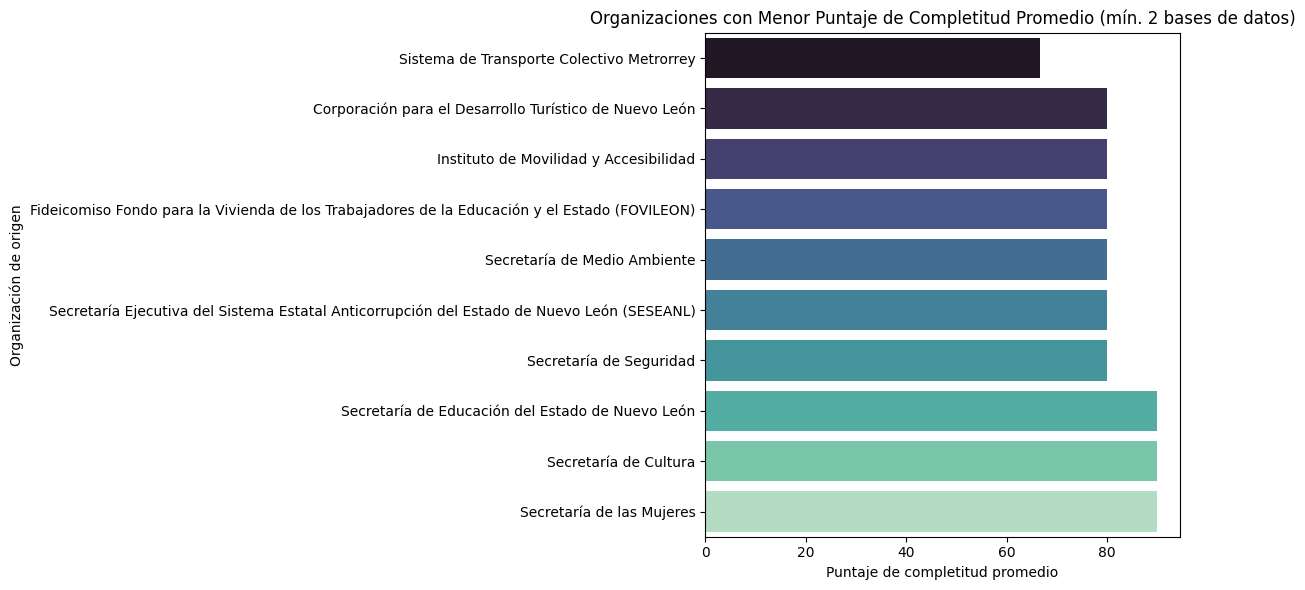

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

org_summary = score_df.groupby('Organizacion de origen').agg(
    num_bases=('Nombre de la base de datos', 'count'),
    bases_vencidas=('vigente', lambda s: (s == 0).sum()),
    score_promedio=('score_completitud', 'mean'),
)
org_summary['% vencidas'] = (org_summary['bases_vencidas'] / org_summary['num_bases'] * 100).round(1)
org_summary['score_promedio'] = org_summary['score_promedio'].round(1)

print("Organizaciones con más bases de datos vencidas (top 10):\n")
display(org_summary.sort_values('bases_vencidas', ascending=False).head(10))

peor_score = org_summary[org_summary['num_bases'] >= 2].sort_values('score_promedio').head(10)
print("\nOrganizaciones con menor puntaje de completitud promedio (con al menos 2 bases de datos):\n")
display(peor_score)

plt.figure(figsize=(12, 6))
sns.barplot(x=peor_score['score_promedio'], y=peor_score.index, hue=peor_score.index, palette='mako', legend=False)
plt.title('Organizaciones con Menor Puntaje de Completitud Promedio (mín. 2 bases de datos)')
plt.xlabel('Puntaje de completitud promedio')
plt.ylabel('Organización de origen')
plt.tight_layout()
plt.show()

#### Puntaje de completitud promedio por grupo

Igual que se hizo por organización, se agrega el puntaje de completitud (0-100) por `Grupo` temático, para tener el mismo indicador a nivel de área de negocio y no solo a nivel de dependencia responsable.

Puntaje de completitud promedio por grupo:



,num_bases,score_promedio
Grupos,,
Administración,2,100.0
Deportes,4,100.0
Turismo,6,100.0
Salud,4,100.0
Asistencia Social,17,97.6
Infraestructura,16,97.5
Perspectiva de Género e Interseccionalidad,6,96.7
Medio Ambiente,8,95.0
Atención Ciudadana,11,94.5


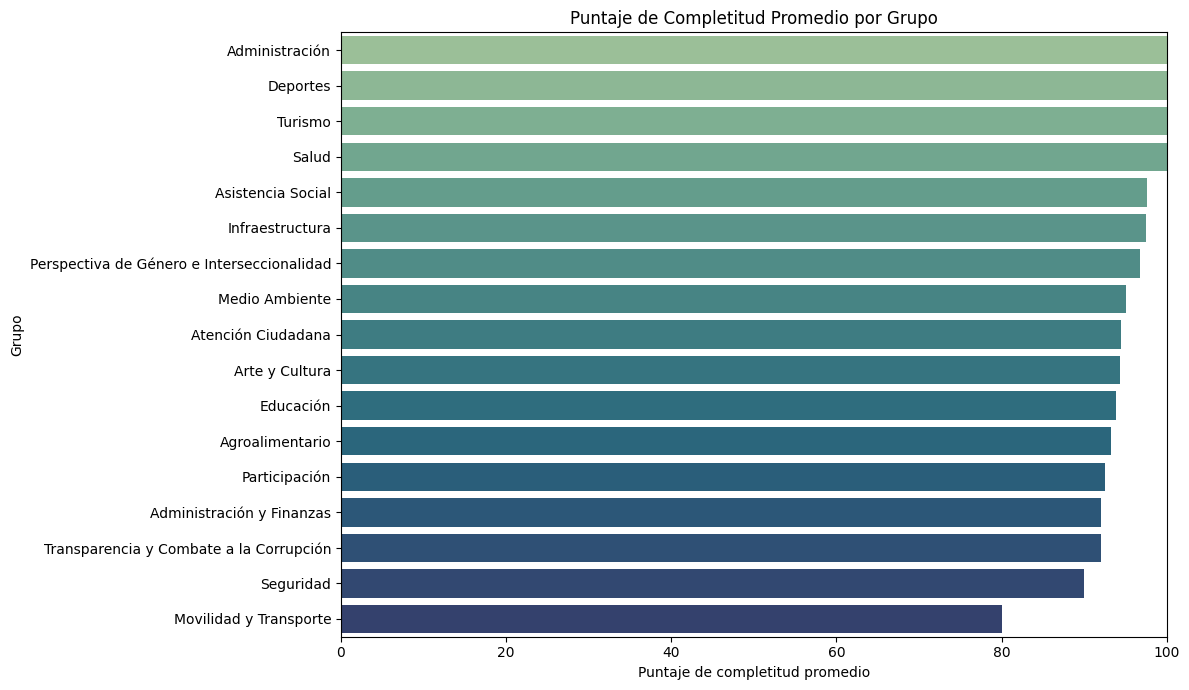

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Expandir 'Grupos' (una base puede pertenecer a varios) y reutilizar el score_df ya calculado
score_grupos = score_df[['Nombre de la base de datos', 'Grupos', 'score_completitud', 'vigente']].copy()
score_grupos['Grupos'] = score_grupos['Grupos'].dropna().astype(str).str.split(';')
score_grupos = score_grupos.explode('Grupos')
score_grupos['Grupos'] = score_grupos['Grupos'].str.strip()

group_score_summary = score_grupos.groupby('Grupos').agg(
    num_bases=('Nombre de la base de datos', 'count'),
    score_promedio=('score_completitud', 'mean'),
).round(1).sort_values('score_promedio', ascending=False)

print("Puntaje de completitud promedio por grupo:\n")
display(group_score_summary)

plt.figure(figsize=(12, 7))
sns.barplot(
    x=group_score_summary['score_promedio'],
    y=group_score_summary.index,
    hue=group_score_summary.index,
    palette='crest',
    legend=False,
)
plt.title('Puntaje de Completitud Promedio por Grupo')
plt.xlabel('Puntaje de completitud promedio')
plt.ylabel('Grupo')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Parte 2: Tabla de Variables por cada Base de Datos

In [30]:
df2 = pd.read_csv('tabla_variables.csv', encoding='latin1')
display(df2.head())

,Nombre variable,Tipo de variable,Base de datos de origen,Descripcion,Rango o valores unicos,% Valores faltantes (N/A)
0,Periodo_fiscal,Entero (integer),Actividades en el LABNL Lab Cultural Ciudadano...,Periodo en el que se realizo la actividad,2022 a 2025,0.0
1,Programa,Categorica,Actividades en el LABNL Lab Cultural Ciudadano...,Nombre del programa del cual se desprenden pro...,Cultura de la Gobernanza; Innovacion Cultural;...,0.0
2,Proyecto,Categorica,Actividades en el LABNL Lab Cultural Ciudadano...,Nombre del proyecto del cual se desprenden act...,Actividades institucionales; Cultura para la I...,0.0
3,Tipo_actividad,Categorica,Actividades en el LABNL Lab Cultural Ciudadano...,Tipo de actividad o evento,Aniversario; Aprender haciendo; Capacitacion; ...,0.0
4,Disciplina,Categorica,Actividades en el LABNL Lab Cultural Ciudadano...,Tipo de disciplina relacionada a las artes y e...,Multidisciplinario; sin dato,0.0


In [31]:
print(df2.columns)

Index(['Nombre variable', 'Tipo de variable', 'Base de datos de origen',
       'Descripcion', 'Rango o valores unicos', '% Valores faltantes (N/A)'],
      dtype='str')


#### Ejemplo: variables del grupo `'Asistencia Social'`

A modo de ejemplo de cómo cruzar `df` (catálogo) con `df2` (variables), se listan todas las variables — y su % de valores faltantes — de las bases de datos que pertenecen al grupo `'Asistencia Social'`. El mismo patrón se puede reutilizar cambiando el nombre del grupo.

In [32]:
# 1. Filtrar df para encontrar las bases de datos del grupo 'Asistencia Social'
# La columna 'Grupos' puede contener múltiples grupos separados por ';'
asistencia_social_databases = df[df['Grupos'].astype(str).str.contains('Asistencia Social', na=False, case=False)]

# Obtener los nombres únicos de las bases de datos de 'Asistencia Social'
# Aseguramos que los nombres sean compatibles con la columna 'Base de datos de origen' en df2
database_names_asistencia_social = asistencia_social_databases['Nombre de la base de datos'].unique()

print(f"Bases de datos en el grupo 'Asistencia Social' ({len(database_names_asistencia_social)}):")
for db_name in database_names_asistencia_social:
    print(f"- {db_name}")

# 2. Buscar en df2 las variables asociadas a esas bases de datos
# Usamos isin para filtrar df2 por los nombres de las bases de datos encontrados
variables_asistencia_social = df2[df2['Base de datos de origen'].isin(database_names_asistencia_social)]

print(f"\nVariables encontradas para las bases de datos de 'Asistencia Social' ({len(variables_asistencia_social)}):")
# Mostramos las variables únicas y sus respectivas bases de datos, incluyendo el porcentaje de valores faltantes
if not variables_asistencia_social.empty:
    # Para evitar duplicados de variables si aparecen en varias bases de datos del grupo
    # o si una base de datos tiene la misma variable con diferentes descripciones, etc.
    # Agrupamos por 'Base de datos de origen' y listamos las variables para cada una
    # Incluimos el porcentaje de valores faltantes
    for db_origin in database_names_asistencia_social:
        db_vars = variables_asistencia_social[variables_asistencia_social['Base de datos de origen'] == db_origin]
        if not db_vars.empty:
            print(f"  Base de datos: '{db_origin}'")
            # Imprimir solo las variables únicas de esa base de datos y su % de N/A
            for index, row in db_vars[['Nombre variable', '% Valores faltantes (N/A)']].drop_duplicates().iterrows():
                print(f"    - {row['Nombre variable']} (Nulos: {row['% Valores faltantes (N/A)']}%)")
else:
    print("No se encontraron variables asociadas a las bases de datos de 'Asistencia Social' en df2.")

Bases de datos en el grupo 'Asistencia Social' (17):
- Estadística de quejas, peticiones, sugerencias y/o reconocimientos del sistema OpinaRed
- Atenciones del 070 por canal
- LOTES REGULARIZADOS CONTRATADOS
- SUBSIDIO AYUDAMOS A TU HOGAR
- LOTES ASIGNADOS
- VIVIENDAS REHABILITADAS
- Denuncias de maltrato animal
- Conjunto de Datos IDPNL
- Servicios para el campo
- Listado-Directorio CENDIS
- Cursos y Talleres
- Personas beneficiarias del programa Jefas de Familia
- Directorio de Centros Comunitarios
- Directorio de Centros de Atención Integral para Adolescentes
- Talleres realizados en los Centros Comunitarios de Desarrollo Social
- Personas beneficiarias del programa Impulso a Cuidadoras
- Personas beneficiarias del programa Hambre Cero

Variables encontradas para las bases de datos de 'Asistencia Social' (230):
  Base de datos: 'Estadística de quejas, peticiones, sugerencias y/o reconocimientos del sistema OpinaRed'
    - Fecha_opinion (Nulos: 0.0%)
    - Ambito (Nulos: 0.0%)
    - 

#### Bases de datos del catálogo sin entradas en el diccionario de variables

Se comparan los nombres de bases de datos en `df` (catálogo) contra los nombres en `df2` (diccionario de variables) para detectar cuáles no tienen su diccionario correspondiente en `tabla_variables.csv`. Como el usuario señaló, ambos archivos se extrajeron con una semana de diferencia, así que una parte de la diferencia se explica por bases creadas/borradas en ese lapso; sin embargo, como se ve abajo, también hay un caso de inconsistencia de mayúsculas en el nombre.

In [33]:
# Obtener nombres únicos de bases de datos de df
db_names_df = set(df['Nombre de la base de datos'].unique())

# Obtener nombres únicos de bases de datos de df2
db_names_df2 = set(df2['Base de datos de origen'].unique())

# Encontrar nombres de bases de datos que están en df pero no en df2
db_names_only_in_df = db_names_df - db_names_df2

print(f"Bases de datos en df que no están en df2 ({len(db_names_only_in_df)}):\n")
if db_names_only_in_df:
    for db_name in sorted(list(db_names_only_in_df)):
        print(f"- {db_name}")
else:
    print("No se encontraron bases de datos en df que no estén en df2.")

Bases de datos en df que no están en df2 (4):

- Contrataciones Abiertas de la Dirección General de Adquisiciones y Servicios
- Hecho por Tipo de Violencia
- Hecho por tipo de Violencia
- PROCESO EXTINCIÓN DEL FIDEICOMISO FOMENTO METROPOLITANO DE MONTERREY (FOMERREY)


#### ¿El campo `Diccionario (Si/No)` es confiable?

Se valida si el valor declarado en `Diccionario (Si/No)` coincide con la realidad: si la base de datos efectivamente aparece (o no) en `tabla_variables.csv`. Esto detecta banderas mal marcadas directamente en el catálogo, más allá de la comparación de nombres de la celda anterior.

In [34]:
# Bases marcadas como 'Si' en Diccionario pero sin presencia real en tabla_variables.csv
si_pero_sin_datos = df[(df['Diccionario (Si/No)'] == 'Si') & (~df['Nombre de la base de datos'].isin(db_names_df2))]
print(f"Bases marcadas 'Si' en Diccionario pero sin variables encontradas en tabla_variables.csv: {len(si_pero_sin_datos)}")
if not si_pero_sin_datos.empty:
    display(si_pero_sin_datos[['Nombre de la base de datos', 'Diccionario (Si/No)']])
    print(
        "Aclaración: no es que la bandera 'Diccionario (Si/No)' esté mal puesta en estos casos. "
        "catalogo_datos.csv y tabla_variables.csv se extrajeron con una semana de diferencia, y estas "
        "bases de datos ya no estaban publicadas en la plataforma para cuando se hizo el webscraping de "
        "tabla_variables.csv (fueron borradas en ese lapso). Por eso sí tenían diccionario, pero no quedó "
        "registrado en este segundo archivo."
    )

# Bases marcadas como 'No' en Diccionario pero que sí tienen variables en tabla_variables.csv
no_pero_con_datos = df[(df['Diccionario (Si/No)'] == 'No') & (df['Nombre de la base de datos'].isin(db_names_df2))]
print(f"\nBases marcadas 'No' en Diccionario pero que sí tienen variables en tabla_variables.csv: {len(no_pero_con_datos)}")
if not no_pero_con_datos.empty:
    display(no_pero_con_datos[['Nombre de la base de datos', 'Diccionario (Si/No)']])

Bases marcadas 'Si' en Diccionario pero sin variables encontradas en tabla_variables.csv: 2


,Nombre de la base de datos,Diccionario (Si/No)
10,Hecho por Tipo de Violencia,Si
101,Hecho por tipo de Violencia,Si


Aclaración: no es que la bandera 'Diccionario (Si/No)' esté mal puesta en estos casos. catalogo_datos.csv y tabla_variables.csv se extrajeron con una semana de diferencia, y estas bases de datos ya no estaban publicadas en la plataforma para cuando se hizo el webscraping de tabla_variables.csv (fueron borradas en ese lapso). Por eso sí tenían diccionario, pero no quedó registrado en este segundo archivo.

Bases marcadas 'No' en Diccionario pero que sí tienen variables en tabla_variables.csv: 0


#### Otros hallazgos de calidad de datos en `catalogo_datos.csv`

Dos problemas adicionales de la plataforma, no cubiertos arriba, que vale la pena documentar para el equipo de GeoStats:

1.  **Nombres de bases de datos duplicados:** hay bases de datos con exactamente el mismo nombre público pero distinto identificador interno (`_id_ckan`), es decir, son registros distintos en CKAN que comparten nombre. Esto dificulta referenciarlas sin ambigüedad (por ejemplo, al cruzar con `tabla_variables.csv` por nombre).
2.  **Variables sin nombre en el diccionario:** en `tabla_variables.csv` hay al menos una fila con `'Nombre variable'` vacío, lo que sugiere un problema de captura en el diccionario de esa base de datos.

In [35]:
# 1. Nombres de bases de datos duplicados en el catálogo (mismo nombre, distinto _id_ckan)
dup_names = df[df['Nombre de la base de datos'].duplicated(keep=False)].sort_values('Nombre de la base de datos')
print(f"Bases de datos con nombre duplicado: {dup_names['Nombre de la base de datos'].nunique()} nombres, "
      f"{len(dup_names)} filas en total.\n")
display(dup_names[['Nombre de la base de datos', '_id_ckan']])

# 2. Variables sin nombre en el diccionario de variables
missing_var_name = df2[df2['Nombre variable'].isnull()]
print(f"\nFilas en tabla_variables.csv sin 'Nombre variable': {len(missing_var_name)}")
if not missing_var_name.empty:
    display(missing_var_name)

Bases de datos con nombre duplicado: 2 nombres, 6 filas en total.



,Nombre de la base de datos,_id_ckan
18,Denuncias de maltrato animal,c7d7aa11-9060-4516-9a73-3b009edaebaf
78,Denuncias de maltrato animal,fbdb8652-36f1-405a-ba3a-cfc153130ecc
113,Denuncias de maltrato animal,cf7eebca-83f2-40db-bd30-32de3f5dd425
66,Solicitudes de Acceso a la Información,7945215e-9b80-4078-9f22-ff1a5414cee8
77,Solicitudes de Acceso a la Información,f9168614-c551-44f7-ba43-b0bf3c970564
89,Solicitudes de Acceso a la Información,db8413d0-deb9-4401-89e1-9993b228d810



Filas en tabla_variables.csv sin 'Nombre variable': 1


,Nombre variable,Tipo de variable,Base de datos de origen,Descripcion,Rango o valores unicos,% Valores faltantes (N/A)
189,NaN,Categorica,Atenciones del 070 por canal,Sin descripcion,Abasolo; Agualeguas; Allende; Anáhuac; Apodaca...,98.3


Al investigar el caso de "Denuncias de maltrato animal" dentro de la página web, se puede ver a partir de su descripción que cada una de las bases con nombre duplicado corresponde a los datos de un diferente periodo, desde 2024 hasta 2026. Para evitar confusión, sería recomendable agregar un diferenciador dentro del nombre de cada base de datos.

### Análisis de Variables en `tabla_variables.csv`

Este apartado se enfoca en el archivo `tabla_variables.csv` (representado por `df2`), explorando la distribución de los tipos de variables y el porcentaje de valores faltantes.

#### Variables por base de datos y bases con más valores faltantes

Se cuenta cuántas variables tiene cada base de datos en `tabla_variables.csv` y se calcula el % promedio de valores faltantes por base de datos (no solo por grupo), para identificar tanto bases muy pequeñas como las de peor calidad. Es una tabla pensada para alimentar directamente un ranking en el futuro dashboard.

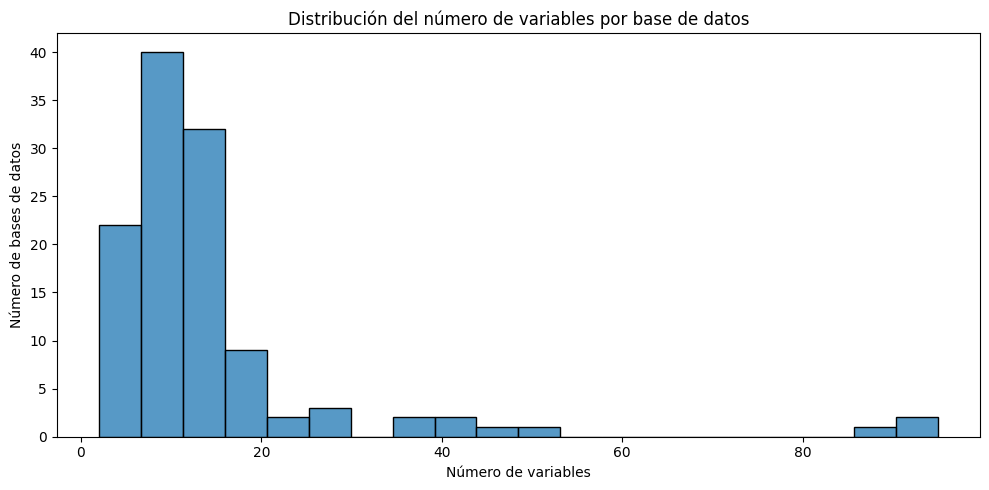

Bases de datos con MENOS variables (top 10):
 Base de datos de origen
Infraestructura de agua                                 4
Agua reutilizada                                        4
Saldos de rendimientos de aportación del Fideicomiso    4
Pueblos Mágicos Nuevo León                              4
Personas beneficiarias del programa Hambre Cero         4
Planteles Educativos                                    4
Residuos Sólidos Urbanos                                4
Fuentes de agua                                         3
Insumos Políticas Públicas                              3
Visitantes a Parques de Nuevo León                      2
dtype: int64

Bases de datos con mayor % promedio de valores faltantes (top 10):



,% promedio de nulos
Base de datos de origen,
Declaraciones oficiales de la Oficina Ejecutiva,98.750000
Proyectos de FIDECULTURAL 2019-2024,94.320000
Resultados del clima laboral de la Administración Pública Estatal,93.740000
Espacios participativos en el Gobierno del Estado de Nuevo León,78.770526
Solicitudes de Información,76.800000
Solicitudes de Información Fid. 2284 Tren Suburbano,75.000000
Atenciones del 070 por canal,63.600000
Solicitudes de acceso a la información recibidas por el Sistema Estatal de Información,55.400000
Atenciones Ciudadanas,55.277778


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

vars_per_db = df2.groupby('Base de datos de origen').size().sort_values(ascending=False)
avg_nulls_per_db = df2.groupby('Base de datos de origen')['% Valores faltantes (N/A)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.histplot(vars_per_db, bins=20)
plt.title('Distribución del número de variables por base de datos')
plt.xlabel('Número de variables')
plt.ylabel('Número de bases de datos')
plt.tight_layout()
plt.show()

print("Bases de datos con MENOS variables (top 10):\n", vars_per_db.tail(10))

print("\nBases de datos con mayor % promedio de valores faltantes (top 10):\n")
display(avg_nulls_per_db.head(10).to_frame(name='% promedio de nulos'))

### Análisis Combinado: Tipos de Variables por Grupo

Para obtener una visión más rica, combinaremos la información de `df` (catálogo de bases de datos) y `df2` (variables por base de datos). Esto nos permitirá analizar la composición de tipos de variables dentro de cada `Grupo` al que pertenece una base de datos.

In [37]:
# 1. Identificar nombres de bases de datos comunes en ambos DataFrames
db_names_df = set(df['Nombre de la base de datos'].unique())
db_names_df2 = set(df2['Base de datos de origen'].unique())

common_db_names = db_names_df.intersection(db_names_df2)

print(f"Se encontraron {len(common_db_names)} bases de datos comunes en ambos archivos.")

# 2. Filtrar df y df2 para incluir solo estas bases de datos comunes
df_common = df[df['Nombre de la base de datos'].isin(common_db_names)].copy()
df2_common = df2[df2['Base de datos de origen'].isin(common_db_names)].copy()

# 3. Expandir la columna 'Grupos' en df_common para manejar múltiples grupos por base de datos
df_common['Grupos'] = df_common['Grupos'].dropna().astype(str).str.split(';')
df_exploded_groups = df_common.explode('Grupos')

# Limpiar espacios en blanco después de explotar
df_exploded_groups['Grupos'] = df_exploded_groups['Grupos'].str.strip()

# 4. Unir la información de grupos con la información de variables
# Renombrar 'Grupos' a 'Grupo' para claridad, ya que ahora es de un solo valor por fila
# Seleccionar solo las columnas necesarias para la unión y el análisis
merged_analysis_df = pd.merge(
    df_exploded_groups[['Nombre de la base de datos', 'Grupos']],
    df2_common[['Base de datos de origen', 'Nombre variable', 'Tipo de variable']],
    left_on='Nombre de la base de datos',
    right_on='Base de datos de origen',
    how='inner'
)

# Mostrar las primeras filas del DataFrame combinado para verificación
print("\nPrimeras filas del DataFrame combinado para análisis:")
display(merged_analysis_df.head())

# 5. Calcular la frecuencia y el porcentaje de cada tipo de variable por grupo
# Contar cuántas veces aparece cada 'Tipo de variable' dentro de cada 'Grupos'
type_counts_by_group = merged_analysis_df.groupby(['Grupos', 'Tipo de variable']).size().unstack(fill_value=0)

# Calcular porcentajes
type_percentages_by_group = type_counts_by_group.apply(lambda x: x / x.sum() * 100, axis=1)

print("\nDistribución de Tipos de Variable por Grupo (porcentaje):")
display(type_percentages_by_group)

Se encontraron 117 bases de datos comunes en ambos archivos.



Primeras filas del DataFrame combinado para análisis:


,Nombre de la base de datos,Grupos,Base de datos de origen,Nombre variable,Tipo de variable
0,Matricula Universidad Politécnica de Apodaca,Educación,Matricula Universidad Politécnica de Apodaca,Anualidad,Entero (integer)
1,Matricula Universidad Politécnica de Apodaca,Educación,Matricula Universidad Politécnica de Apodaca,Periodo_cuatrimestral,Categorica
2,Matricula Universidad Politécnica de Apodaca,Educación,Matricula Universidad Politécnica de Apodaca,Estado_actual,Categorica
3,Matricula Universidad Politécnica de Apodaca,Educación,Matricula Universidad Politécnica de Apodaca,Grupo,Categorica
4,Matricula Universidad Politécnica de Apodaca,Educación,Matricula Universidad Politécnica de Apodaca,Cuatrimestre,Entero (integer)



Distribución de Tipos de Variable por Grupo (porcentaje):


Tipo de variable,Booleana,Categorica,Entero (integer),Numerica (decimal),Texto libre,Tiempo (fecha/hora),Vacia / sin datos
Grupos,,,,,,,
Administración,0.000000,22.222222,51.851852,0.000000,22.222222,3.703704,0.000000
Administración y Finanzas,1.600000,44.000000,28.000000,1.600000,14.400000,4.800000,5.600000
Agroalimentario,0.000000,48.275862,13.793103,27.586207,10.344828,0.000000,0.000000
Arte y Cultura,0.000000,46.583851,41.614907,0.000000,7.453416,3.726708,0.621118
Asistencia Social,4.347826,38.260870,48.695652,0.000000,6.521739,2.173913,0.000000
Atención Ciudadana,6.206897,46.896552,26.896552,2.758621,13.793103,3.448276,0.000000
Deportes,0.000000,56.862745,29.411765,1.960784,11.764706,0.000000,0.000000
Educación,1.562500,34.375000,39.843750,2.343750,21.875000,0.000000,0.000000
Infraestructura,0.000000,30.069930,46.153846,6.293706,17.482517,0.000000,0.000000


#### Visualización de Tipos de Variables por Grupo

Esta gráfica de barras apiladas muestra la composición de los tipos de variables para cada grupo de bases de datos. Permite identificar qué tipos de datos son predominantes en distintas áreas temáticas.

<Figure size 1600x1000 with 0 Axes>

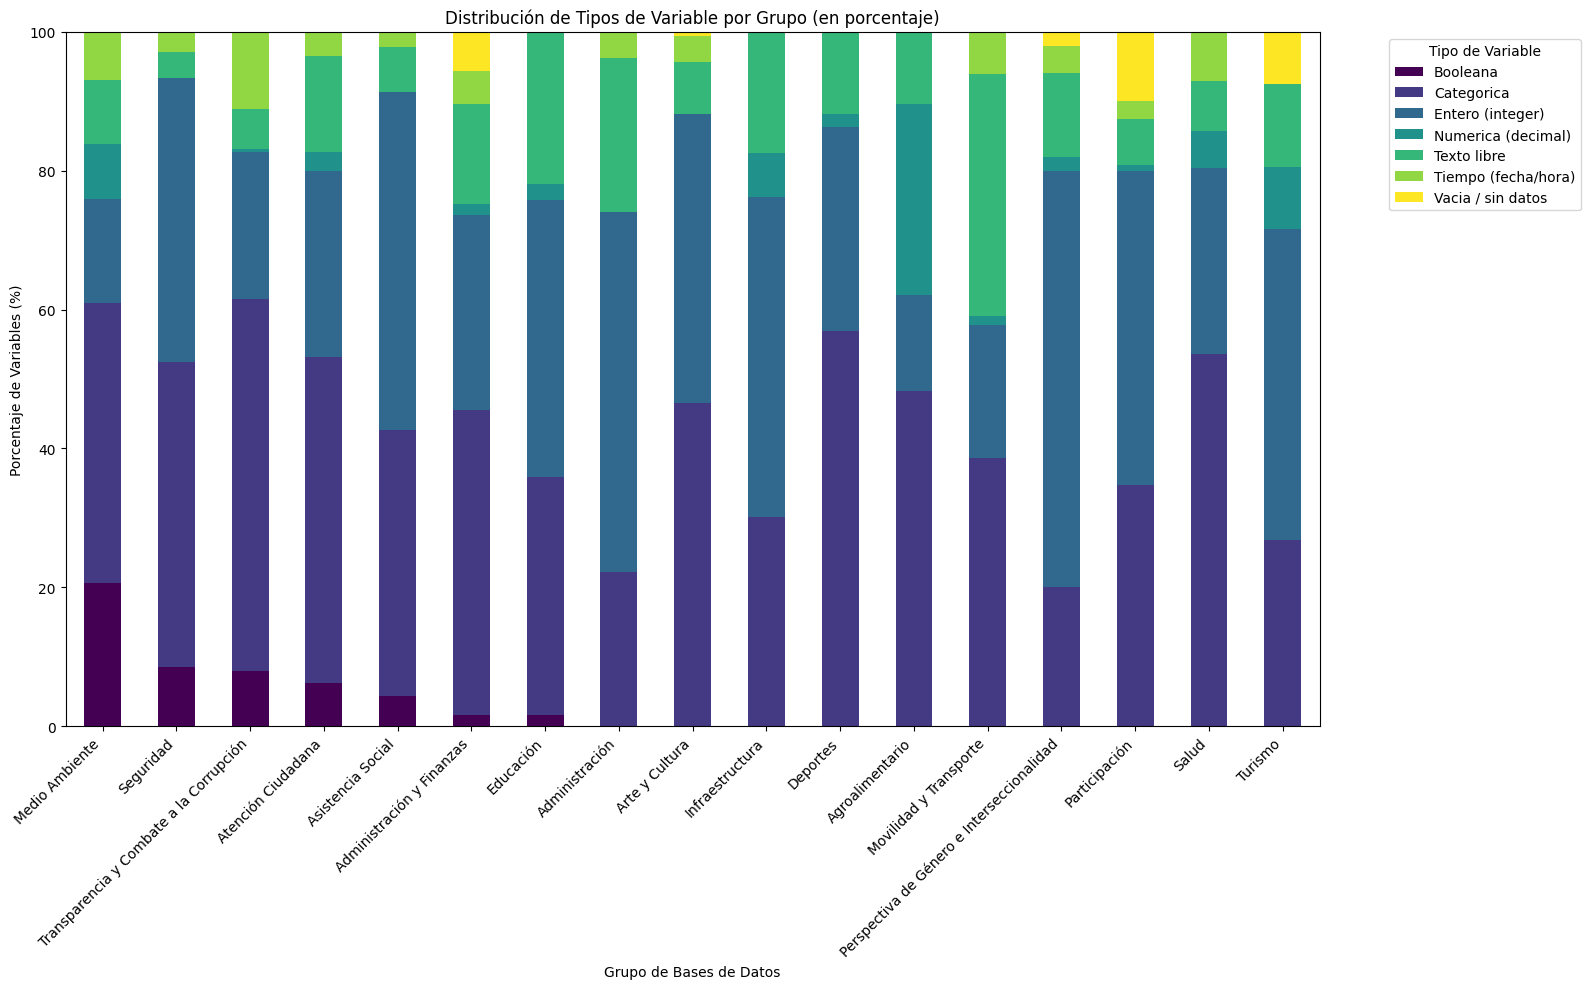

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar los grupos por el número total de variables o por un criterio relevante si se desea
type_percentages_by_group.sort_values(by=type_percentages_by_group.columns[0], ascending=False, inplace=True)

plt.figure(figsize=(16, 10))
# Usar un mapa de colores que se distinga bien
colors = sns.color_palette("tab20", n_colors=type_percentages_by_group.shape[1])

type_percentages_by_group.plot(kind='bar', stacked=True, figsize=(16, 10), cmap='viridis')

plt.title('Distribución de Tipos de Variable por Grupo (en porcentaje)')
plt.xlabel('Grupo de Bases de Datos')
plt.ylabel('Porcentaje de Variables (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Porcentaje Promedio de Valores Nulos por Grupo de Base de Datos

A continuación, se visualiza el porcentaje promedio de valores faltantes para las variables dentro de cada `Grupo` de bases de datos. Esta gráfica enlaza la información de `df` (para los grupos) y `df2` (para el porcentaje de nulos por variable), proporcionando una visión consolidada de la calidad de los datos a nivel de grupo.

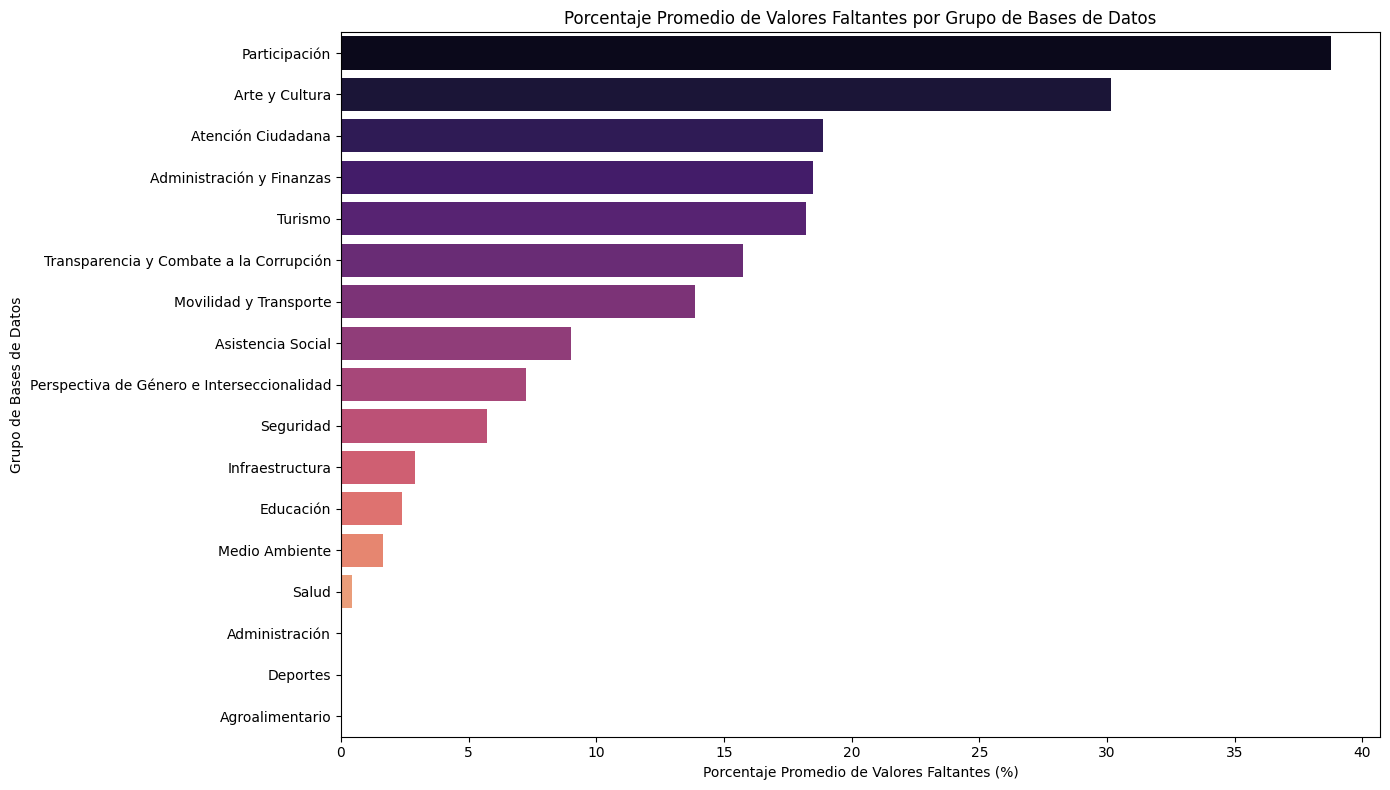

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que la columna '% Valores faltantes (N/A)' sea numérica en df2_common
df2_common['% Valores faltantes (N/A)'] = pd.to_numeric(df2_common['% Valores faltantes (N/A)'], errors='coerce')

# Unir merged_analysis_df con df2_common para obtener los porcentajes de nulos
# La unión se realiza por 'Base de datos de origen' y 'Nombre variable'
df_grouped_nulls = pd.merge(
    merged_analysis_df,
    df2_common[['Base de datos de origen', 'Nombre variable', '% Valores faltantes (N/A)']],
    on=['Base de datos de origen', 'Nombre variable'],
    how='left'
)

# Calcular el porcentaje promedio de valores faltantes por grupo
avg_null_percentage_by_group = df_grouped_nulls.groupby('Grupos')['% Valores faltantes (N/A)'].mean().sort_values(ascending=False)

if not avg_null_percentage_by_group.empty:
    plt.figure(figsize=(14, 8))
    sns.barplot(
        x=avg_null_percentage_by_group.values,
        y=avg_null_percentage_by_group.index,
        hue=avg_null_percentage_by_group.index,
        palette='magma',
        legend=False,
    )
    plt.title('Porcentaje Promedio de Valores Faltantes por Grupo de Bases de Datos')
    plt.xlabel('Porcentaje Promedio de Valores Faltantes (%)')
    plt.ylabel('Grupo de Bases de Datos')
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo calcular el porcentaje promedio de valores faltantes por grupo.")

## Resumen de Hallazgos Clave del EDA

### Catálogo General de Datos (`catalogo_datos.csv`)

*   **Volumen de Datos:** el catálogo contiene **125** bases de datos, lo que indica un volumen considerable de información disponible.
*   **Fechas de Creación:** la distribución de las fechas de creación muestra picos en ciertos periodos, sugiriendo iniciativas de publicación de datos o esfuerzos concentrados en momentos específicos.
*   **Organizaciones Contribuyentes:** se identificaron las 10 organizaciones con el mayor número de bases de datos, destacando la **Secretaría de Administración** (8) y la **Secretaría de Igualdad e Inclusión** (7) como las principales contribuyentes.
*   **Etiquetas y Grupos:** la columna `Etiquetas` presenta una gran diversidad (146 valores distintos usados, frente a un banco oficial reportado de solo 29), y no hay un esquema estandarizado, lo que dificulta la clasificación. Los `Grupos` `Asistencia Social` (17) e `Infraestructura` (16) son los que agrupan la mayor cantidad de bases de datos.
*   **Calidad de los Metadatos:**
    *   **Diccionarios de Variables:** **2** bases de datos carecen de diccionario de variables según su bandera `Diccionario (Si/No)`, y la validación cruzada contra `tabla_variables.csv` encontró además banderas que no coinciden con la realidad (ver sección correspondiente).
    *   **Actualizaciones:** tomando el **12 de septiembre de 2026** como fecha de referencia fija (para que el resultado sea reproducible y no cambie según el día en que se corra el notebook), había **39** bases de datos cuya fecha de actualización esperada ya había pasado según su propia periodicidad declarada — cerca de un tercio del catálogo. El grupo con mayor proporción de bases vencidas se identifica en la gráfica de cumplimiento por grupo.
    *   **Valores Nulos:** la columna `Fuente` presenta la mayor cantidad de valores nulos (**~65.5%** del total de nulos del DataFrame), seguida por `Grupos` (~22.6%).
    *   **Descripciones:** un número de bases de datos tiene descripciones vacías o de muy pocas palabras (ver sección de completitud de descripciones), lo que limita entender su contenido sin abrir el archivo.
    *   **Errores de captura detectados:** un valor de `'mayo 2026'` (una fecha) capturado en el campo `Periodo de actualizacion`, que debería contener una periodicidad; nombres de bases de datos duplicados con distinto `_id_ckan` (p. ej. `Denuncias de maltrato animal` y `Solicitudes de Acceso a la Información`, cada una con 3 registros); y una inconsistencia de mayúsculas entre catálogo y diccionario (`Hecho por Tipo de Violencia` vs. `Hecho por tipo de Violencia`).
*   **Formatos y Licencias:** la mayoría de las bases de datos están en formato **CSV** y se rigen por la licencia **Open Data Commons Attribution License**.

### Variables Específicas (`tabla_variables.csv`)

*   **Disponibilidad:** se encontró que **4** nombres de bases de datos listados en el catálogo (`df`) no tienen sus variables detalladas en `tabla_variables.csv` (`df2`) — parte de esto se explica por la semana de diferencia entre ambas extracciones, y parte por el problema de mayúsculas señalado arriba.
*   **Tipos de Variables por Grupo:** el análisis combinado reveló la predominancia de ciertos tipos de variables (p. ej. `Texto libre`, `Numérica (decimal)`, `Entero (integer)`) en grupos específicos, lo cual es útil para entender la naturaleza de los datos en cada área temática.
*   **Nulos en Variables:** el grupo con mayor porcentaje promedio de valores faltantes en sus variables (ver gráfica de barras por grupo) indica una menor completitud de los datos en esa área; el ranking por base de datos individual identifica además cuáles bases específicas son las de peor calidad.
*   **Calidad del diccionario:** al menos 1 fila de `tabla_variables.csv` no tiene `Nombre variable`, un problema de captura a corregir en el proceso de scraping o en la fuente.

### Posibles próximos pasos

*   **Para la plataforma:** estandarizar el banco de etiquetas y forzarlo como catálogo cerrado al publicar; validar el campo `Periodo de actualizacion` contra una lista fija; revisar/depurar los identificadores duplicados detectados; y exigir una descripción mínima al publicar una base de datos.
*   **Para GeoStats:** priorizar como fuente de nuevos prototipos los grupos con mayor volumen (`Asistencia Social`, `Infraestructura`) y con mayor % de bases vencidas; y cruzar la lista de bases "vencidas" y de peor calidad con las organizaciones que las mantienen, para dar seguimiento directo.
*   **Para el dashboard/reporte:** este notebook ya deja listas varias tablas pensadas para eso — cumplimiento de actualización por grupo, ranking de bases con más nulos, conteo de variables por base y completitud de descripciones — que se pueden convertir directamente en KPIs o filtros.